<div style="
background: linear-gradient(135deg, #0f2027 0%, #203a43 45%, #2c5364 100%);
padding: 36px 28px;
border-radius: 16px;
margin-bottom: 24px;
font-family: 'Segoe UI', Arial, sans-serif;
">

<h1 style="
color: #e0fbfc;
font-size: 2.2em;
margin: 0 0 10px 0;
font-weight: 700;
line-height: 1.2;
">
MILPÍN AgTech — Predicción Agrícola con XGBoost
</h1>

<p style="
color: #bde0fe;
font-size: 1.02em;
margin-bottom: 20px;
line-height: 1.5;
">
Consumo de Agua y Rendimiento Agrícola ·
Modelado Predictivo Multivariable ·
Valle del Yaqui, Sonora
</p>

<div style="
display: flex;
flex-wrap: wrap;
gap: 10px;
margin-bottom: 24px;
">

<span style="
background: rgba(255,255,255,0.12);
color: #edf6f9;
padding: 6px 14px;
border-radius: 18px;
font-size: 0.78em;
">
Valle del Yaqui · Sonora · Agricultura de Precisión
</span>

<span style="
background: rgba(255,255,255,0.12);
color: #edf6f9;
padding: 6px 14px;
border-radius: 18px;
font-size: 0.78em;
">
XGBoost · scikit-learn · pandas · SHAP
</span>

<span style="
background: rgba(255,255,255,0.12);
color: #edf6f9;
padding: 6px 14px;
border-radius: 18px;
font-size: 0.78em;
">
ET₀ · Kc FAO-56 · Balance Hídrico
</span>

<span style="
background: rgba(255,255,255,0.12);
color: #edf6f9;
padding: 6px 14px;
border-radius: 18px;
font-size: 0.78em;
">
Predicción Multiobjetivo · Agua y Rendimiento
</span>

</div>

<div style="
background: rgba(255,255,255,0.08);
padding: 16px;
border-radius: 12px;
display: inline-block;
width: fit-content;
max-width: fit-content;
">

<table style="
border-collapse: collapse;
color: #f1faee;
font-size: 0.88em;
min-width: 720px;
">

<thead>

<tr>

<th style="
text-align: left;
padding: 10px 14px;
border: 1px solid rgba(255,255,255,0.18);
background: rgba(255,255,255,0.05);
">
Modelo
</th>

<th style="
text-align: left;
padding: 10px 14px;
border: 1px solid rgba(255,255,255,0.18);
background: rgba(255,255,255,0.05);
">
Target
</th>

<th style="
text-align: left;
padding: 10px 14px;
border: 1px solid rgba(255,255,255,0.18);
background: rgba(255,255,255,0.05);
">
Unidad
</th>

</tr>

</thead>

<tbody>

<tr>

<td style="
padding: 12px 14px;
border: 1px solid rgba(255,255,255,0.18);
">
M1 — Consumo de agua
</td>

<td style="
padding: 12px 14px;
border: 1px solid rgba(255,255,255,0.18);
">

<code style="
background: rgba(255,255,255,0.12);
padding: 3px 7px;
border-radius: 5px;
color: #ffffff;
font-size: 0.92em;
">
volumen_agua_total_m3_ha
</code>

</td>

<td style="
padding: 12px 14px;
border: 1px solid rgba(255,255,255,0.18);
">
m³/ha por ciclo
</td>

</tr>

<tr>

<td style="
padding: 12px 14px;
border: 1px solid rgba(255,255,255,0.18);
">
M2 — Rendimiento agrícola
</td>

<td style="
padding: 12px 14px;
border: 1px solid rgba(255,255,255,0.18);
">

<code style="
background: rgba(255,255,255,0.12);
padding: 3px 7px;
border-radius: 5px;
color: #ffffff;
font-size: 0.92em;
">
rendimiento_real_ton_ha
</code>

</td>

<td style="
padding: 12px 14px;
border: 1px solid rgba(255,255,255,0.18);
">
ton/ha por ciclo
</td>

</tr>

</tbody>

</table>

</div>

</div>

---

# Objetivos del Notebook

1. **Exploración de datos agrícolas** — análisis climático, hídrico y productivo  
2. **Feature Engineering físico-agronómico** — variables derivadas FAO-56 y balance hídrico  
3. **Fundamentos matemáticos** — Gradient Boosting y árboles ensamblados  
4. **Entrenamiento XGBoost** — modelos robustos para regresión multivariable  
5. **Predicción dual** — consumo de agua y rendimiento agrícola  
6. **Interpretabilidad avanzada** — SHAP values y feature importance  
7. **Evaluación estadística** — RMSE, MAE, R² y validación temporal  
8. **Diagnóstico de diversidad sintética** — entropía, cobertura y bimodalidad  

---


> **Alcance del modelo**  
> Este notebook utiliza datos sintéticos generados mediante simulaciones físico-agronómicas avanzadas.  
> Los resultados evalúan la capacidad predictiva del modelo bajo escenarios controlados y no representan todavía desempeño operativo en producción real del DR-041.

---

> **Objetivo técnico**  
> Construir un pipeline reproducible de agricultura de precisión capaz de integrar clima, suelo, manejo agronómico e IoT para predicción inteligente de consumo hídrico y productividad agrícola.

## 0. Configuración e imports

In [5]:
import warnings

warnings.filterwarnings("ignore")


import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import matplotlib.ticker as mticker

import seaborn as sns

import time


from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb


plt.rcParams.update({

    "figure.dpi": 120,

    "figure.figsize": (11, 5),

    "axes.spines.top": False,

    "axes.spines.right": False,

    "font.size": 11,

})

sns.set_palette("Set2")

SEED = 42

np.random.seed(SEED)


print(f"numpy    {np.__version__}")

print(f"XGBoost  {xgb.__version__}")

numpy    2.4.4
XGBoost  3.2.0


In [6]:
# ══════════════════════════════════════════════════════════════════
#  AJUSTA N_SAMPLES SEGÚN TU OBJETIVO
#  ────────────────────────────────────────────────────────────────
#   10_000  → benchmark rápido (<30s entrenamiento)
#   50_000  → RECOMENDADO: balance óptimo señal/tiempo
#  300_000  → prueba de escala (~3-5 min)
# 1_000_000 → stress test (~20-30 min, requiere >=8 GB RAM)
#
#  Con el generador v3 (alta diversidad), la convergencia ocurre más
#  tarde (~80k-150k muestras) gracias a:
#  - Heterogeneidad regional y de arquetipos de agricultor
#  - Variabilidad inter-anual (ENSO, drift climático)
#  - Eventos extremos y estrés por salinidad
#  - Ruido IoT y comportamientos no-lineales
# ══════════════════════════════════════════════════════════════════
N_SAMPLES = 1_000_000
AÑO_RANGO = (2014, 2025)  # rango inter-anual para variabilidad ENSO/drift

## 1. Generadores de datos sintéticos

### v2 — Generador base (referencia)
Implementación vectorizada original. Converge rápido (~20-30k muestras) porque las relaciones
son casi deterministas: `vol_agua ≈ (ETc - lluvia) × 10 / ef`. Sirve como baseline.

### v3 — Generador de alta diversidad estadística
Añade 10 capas de complejidad sobre v2 para que el modelo necesite más datos y aprenda
patrones más robustos. Ver Sección 1b para la implementación detallada.

| N filas  | v2 gen time | v3 gen time |
|----------|-------------|-------------|
| 10 k     | ~0.1 s      | ~0.3 s      |
| 300 k    | ~2 s        | ~5 s        |
| 1 M      | ~8 s        | ~20 s       |

In [7]:
def generar_datos(n=50_000, seed=42, ruido_factor=1.0):

    rng = np.random.default_rng(seed)


    CULTIVOS = ["Maíz", "Frijol", "Algodón", "Uva", "Chile"]

    SUELOS   = ["franco", "franco-arcilloso", "franco-arenoso", "arcilloso"]

    SISTEMAS = ["gravedad", "aspersion", "goteo", "microaspersion"]


    CULT = {

        "Maíz":    dict(dias=(130,150), kc=0.847, ky=1.25, ym=10.5),

        "Frijol":  dict(dias=( 90,110), kc=0.838, ky=1.15, ym=2.5 ),

        "Algodón": dict(dias=(165,200), kc=0.869, ky=0.85, ym=4.0 ),

        "Uva":     dict(dias=(180,215), kc=0.786, ky=0.85, ym=25.0),

        "Chile":   dict(dias=(110,130), kc=0.868, ky=1.10, ym=35.0),

    }

    SUELO = {

        "franco":           dict(cc=0.30, pmp=0.16),

        "franco-arcilloso": dict(cc=0.36, pmp=0.20),

        "franco-arenoso":   dict(cc=0.24, pmp=0.12),

        "arcilloso":        dict(cc=0.42, pmp=0.22),

    }

    EFIC = {"gravedad":0.50, "aspersion":0.75, "goteo":0.90, "microaspersion":0.85}


    cultivos = rng.choice(CULTIVOS, n)

    suelos   = rng.choice(SUELOS,   n)

    sistemas = rng.choice(SISTEMAS, n)


    kc_arr  = np.array([CULT[c]["kc"]      for c in cultivos])

    ky_arr  = np.array([CULT[c]["ky"]      for c in cultivos])

    ym_arr  = np.array([CULT[c]["ym"]      for c in cultivos])

    dmin    = np.array([CULT[c]["dias"][0] for c in cultivos])

    dmax    = np.array([CULT[c]["dias"][1] for c in cultivos])

    cc_arr  = np.array([SUELO[s]["cc"]     for s in suelos])

    pmp_arr = np.array([SUELO[s]["pmp"]    for s in suelos])

    ef_arr  = np.array([EFIC[s]            for s in sistemas])


    area_ha    = rng.uniform(5.0, 80.0, n).round(2)

    doy        = rng.integers(1, 365, n)

    dias_ciclo = (dmin + rng.random(n) * (dmax - dmin)).astype(int)

    prof_raiz  = rng.uniform(0.45, 0.70, n).round(3)


    # ET0: sinusoide estacional calibrada al Valle del Yaqui

    et0_prom = np.clip(

        6.0 + 2.5 * np.sin(2*np.pi*(doy-81)/365) + rng.normal(0, 0.5*ruido_factor, n),

        3.5, 9.5).round(3)

    et0_max  = np.clip(et0_prom * rng.uniform(1.2,1.6,n), et0_prom+0.5, 11.5).round(3)


    # Lluvia: Gamma con estacionalidad (monzón jul-sep)

    es_verano = (doy >= 152) & (doy <= 273)

    lluvia    = np.clip(

        np.where(es_verano, rng.gamma(2.0,50.0,n), rng.gamma(0.8,20.0,n))

        + rng.normal(0, 5*ruido_factor, n), 0, 350).round(2)


    kc_prom    = np.clip(kc_arr + rng.normal(0, 0.015*ruido_factor, n), 0.60, 0.95).round(3)

    etc_total  = (et0_prom * dias_ciclo * kc_prom).round(2)

    hum_suelo  = np.clip(cc_arr*0.85 + rng.normal(0, 0.025*ruido_factor, n), pmp_arr+0.01, cc_arr).round(4)


    # Déficit hídrico: más probable en sistemas de baja eficiencia

    deficit_prob = np.clip((1-ef_arr)*0.25*ruido_factor, 0, 0.3)

    deficit_hid  = np.where(rng.random(n) < deficit_prob, rng.uniform(0,0.35,n), 0.0).round(4)


    agua_disp = (cc_arr - pmp_arr) * prof_raiz * 1000

    n_riegos  = np.clip(

        np.maximum(1, np.round((etc_total-lluvia).clip(0)/(agua_disp*0.6))).astype(int)

        + rng.integers(-1,2,n), 1, 40)


    # Targets

    deficit_agua = np.maximum(0, etc_total - lluvia)

    vol_agua     = np.clip(

        deficit_agua * 10 / ef_arr * rng.normal(1.0, 0.08*ruido_factor, n),

        2_000, 22_000).round(2)


    # FAO-33: Ya = Ym x (1 - Ky x (1 - ETa/ETc))

    ks          = 1.0 - deficit_hid

    ya_frac     = np.clip(1 - ky_arr*(1-ks), 0.05, 1.0)

    rendimiento = np.clip(

        ym_arr * ya_frac * rng.normal(1.0, 0.07*ruido_factor, n),

        0.3, ym_arr*1.15).round(3)


    return pd.DataFrame({

        "cultivo": cultivos, "tipo_suelo": suelos, "sistema_riego": sistemas,

        "area_ha": area_ha, "dias_ciclo": dias_ciclo, "doy_inicio": doy,

        "capacidad_campo": cc_arr, "punto_marchitez": pmp_arr, "prof_raiz_m": prof_raiz,

        "et0_promedio_mmdia": et0_prom, "et0_maximo_mmdia": et0_max,

        "lluvia_total_mm": lluvia, "etc_total_mm": etc_total, "kc_promedio": kc_prom,

        "humedad_suelo_promedio": hum_suelo, "deficit_hidrico_frac": deficit_hid,

        "n_riegos": n_riegos, "volumen_agua_total_m3_ha": vol_agua,

        "rendimiento_real_ton_ha": rendimiento,

    })


print("Generador listo")

Generador listo


## 1b. Módulos de complejidad estadística (v3)

Diez capas de realismo que transforman el espacio de estados del generador:

| Módulo | Tipo de diversidad añadida |
|--------|--------------------------|
| Regiones | Heterogeneidad espacial ET0/lluvia/salinidad/nivel freático |
| Arquetipos | Heterogeneidad comportamental (over-irrigación, riegos perdidos) |
| Kc por etapa | No-linealidad temporal intra-ciclo (FAO-56 curva 4-etapas) |
| ENSO + drift | Variabilidad inter-anual no-estacionaria |
| Eventos extremos | Multimodalidad en colas (olas de calor, heladas, plagas) |
| Salinidad | Estrés independiente del hídrico (confusor no medido) |
| Ascenso capilar | Interacción nivel freático × riego (heterogeneidad espacial) |
| Percolación | Agua perdida bajo zona radicular (ineficiencia no capturada) |
| Ruido IoT | Error sistemático en sensores (drift, atasco, fallo) |
| Agricultores | Sobre/sub-irrigación según perfil de riesgo del productor |

In [8]:
# ══════════════════════════════════════════════════════════════════
# CONFIGURACIONES BASE — Módulos de complejidad v3
# ══════════════════════════════════════════════════════════════════

# ─── 5 micro-regiones del Valle del Yaqui ────────────────────────
# et0_bias: mm/día sobre media regional | lluvia_mult: multiplicador
# sal_base: CE base dS/m | wt_m: nivel freático promedio (m)
# elev_m: elevación media (m snm)
REGIONES_CONFIG = {
    "Norte":   dict(et0_bias=+0.40, lluvia_mult=0.82, sal_base=0.08, wt_m=3.2, elev_m=35),
    "Sur":     dict(et0_bias=+0.12, lluvia_mult=1.05, sal_base=0.04, wt_m=5.1, elev_m=22),
    "Centro":  dict(et0_bias=+0.00, lluvia_mult=1.00, sal_base=0.05, wt_m=4.6, elev_m=40),
    "Oriente": dict(et0_bias=-0.25, lluvia_mult=1.18, sal_base=0.03, wt_m=6.3, elev_m=85),
    "Costero": dict(et0_bias=+0.28, lluvia_mult=0.88, sal_base=0.14, wt_m=2.4, elev_m=12),
}

# ─── Arquetipos de agricultor ─────────────────────────────────────
# over_irr_mu: sesgo medio de sobre-irrigación (fracción, puede ser negativo)
# over_irr_sd: desviación personal | p_miss: prob de perder un evento de riego
FARMER_TYPES = {
    "conservador": dict(over_irr_mu=0.22, over_irr_sd=0.08, p_miss=0.04),
    "eficiente":   dict(over_irr_mu=0.01, over_irr_sd=0.03, p_miss=0.01),
    "negligente":  dict(over_irr_mu=-0.12,over_irr_sd=0.15, p_miss=0.18),
    "tecnificado": dict(over_irr_mu=0.00, over_irr_sd=0.02, p_miss=0.005),
}

# ─── Kc por etapas FAO-56 (Allen et al. 1998 Tabla 11) ───────────
# kc_ini/dev/med/fin: valor Kc por etapa
# f_ini/dev/med/fin: fracción del ciclo que ocupa cada etapa (suma=1.0)
KC_STAGES = {
    "Maíz":    dict(kc_ini=0.30, kc_dev=0.70, kc_med=1.20, kc_fin=0.60,
                    f_ini=0.10, f_dev=0.30, f_med=0.50, f_fin=0.10),
    "Frijol":  dict(kc_ini=0.40, kc_dev=0.70, kc_med=1.15, kc_fin=0.55,
                    f_ini=0.10, f_dev=0.35, f_med=0.40, f_fin=0.15),
    "Algodón": dict(kc_ini=0.45, kc_dev=0.75, kc_med=1.20, kc_fin=0.60,
                    f_ini=0.08, f_dev=0.30, f_med=0.45, f_fin=0.17),
    "Uva":     dict(kc_ini=0.30, kc_dev=0.65, kc_med=0.85, kc_fin=0.45,
                    f_ini=0.15, f_dev=0.35, f_med=0.35, f_fin=0.15),
    "Chile":   dict(kc_ini=0.40, kc_dev=0.75, kc_med=1.05, kc_fin=0.80,
                    f_ini=0.12, f_dev=0.30, f_med=0.45, f_fin=0.13),
}

# ─── Umbrales de salinidad por cultivo (FAO-33 Maas & Hoffman 1977) ──
# thresh: CE umbral (dS/m), slope: % reducción rendimiento por dS/m > umbral
SAL_THRESH = {"Maíz":1.7, "Frijol":1.0, "Algodón":7.7, "Uva":1.5, "Chile":1.5}
SAL_SLOPE  = {"Maíz":12,  "Frijol":19,  "Algodón":5.2, "Uva":9.6, "Chile":14}

print("Módulos v3 cargados: 5 regiones · 4 arquetipos · Kc 4-etapas · tablas salinidad")

Módulos v3 cargados: 5 regiones · 4 arquetipos · Kc 4-etapas · tablas salinidad


In [9]:
def generar_datos_v3(n=50_000, seed=42, ruido_factor=1.0, año_rango=(2014, 2024)):
    """
    Generador v3 — alta diversidad estadística y realismo agrícola (FAO-56).

    Diferencias clave vs v2 que aumentan la complejidad del espacio de estados:
    - Kc variable por etapa (no constante) → relación no-lineal DOY × demanda hídrica
    - ENSO + drift climático → no-estacionariedad temporal
    - Eventos extremos → multimodalidad en colas de distribuciones
    - Arquetipos de agricultor → varianza comportamental no capturada por features físicos
    - Salinidad → confusor independiente del estrés hídrico
    - Ascenso capilar → interacción nivel freático × déficit (heterogeneidad espacial)
    - Ruido IoT → error de medición sistemático y aleatorio

    Completamente vectorizado: usa índices enteros para lookups (no comprehensions O(n)).
    Compatible con pipeline XGBoost/SHAP/Optuna existente.
    """
    rng = np.random.default_rng(seed)

    # ── Catálogos ─────────────────────────────────────────────────────────
    CULTIVOS = ["Maíz", "Frijol", "Algodón", "Uva", "Chile"]
    SUELOS   = ["franco", "franco-arcilloso", "franco-arenoso", "arcilloso"]
    SISTEMAS = ["gravedad", "aspersion", "goteo", "microaspersion"]
    REGIONES = list(REGIONES_CONFIG.keys())
    FARMERS  = list(FARMER_TYPES.keys())

    CULT = {
        "Maíz":    dict(dias=(130,150), kc=0.847, ky=1.25, ym=10.5,  p_dep=0.55),
        "Frijol":  dict(dias=( 90,110), kc=0.838, ky=1.15, ym=2.5,   p_dep=0.45),
        "Algodón": dict(dias=(165,200), kc=0.869, ky=0.85, ym=4.0,   p_dep=0.65),
        "Uva":     dict(dias=(180,215), kc=0.786, ky=0.85, ym=25.0,  p_dep=0.45),
        "Chile":   dict(dias=(110,130), kc=0.868, ky=1.10, ym=35.0,  p_dep=0.30),
    }
    SUELO = {
        "franco":           dict(cc=0.30, pmp=0.16, ks_mmh=15),
        "franco-arcilloso": dict(cc=0.36, pmp=0.20, ks_mmh=6),
        "franco-arenoso":   dict(cc=0.24, pmp=0.12, ks_mmh=30),
        "arcilloso":        dict(cc=0.42, pmp=0.22, ks_mmh=3),
    }
    EFIC = {"gravedad":0.50, "aspersion":0.75, "goteo":0.90, "microaspersion":0.85}

    # ── Sampling con índices enteros (vectorized lookups) ─────────────────
    ci = rng.integers(0, len(CULTIVOS), n)   # cultivo idx
    si = rng.integers(0, len(SUELOS),   n)   # suelo idx
    ri = rng.integers(0, len(SISTEMAS), n)   # sistema riego idx
    gi = rng.integers(0, len(REGIONES), n)   # region idx
    fi = rng.integers(0, len(FARMERS),  n)   # farmer idx

    cultivos = np.array(CULTIVOS)[ci]
    suelos   = np.array(SUELOS)[si]
    sistemas = np.array(SISTEMAS)[ri]
    regiones = np.array(REGIONES)[gi]
    farmers  = np.array(FARMERS)[fi]
    años     = rng.integers(año_rango[0], año_rango[1] + 1, n)

    # Lookup arrays via índice (O(K) Python + O(n) numpy — escala bien)
    kc_arr  = np.array([CULT[c]["kc"]      for c in CULTIVOS])[ci]
    ky_arr  = np.array([CULT[c]["ky"]      for c in CULTIVOS])[ci]
    ym_arr  = np.array([CULT[c]["ym"]      for c in CULTIVOS])[ci]
    dmin    = np.array([CULT[c]["dias"][0] for c in CULTIVOS])[ci]
    dmax    = np.array([CULT[c]["dias"][1] for c in CULTIVOS])[ci]
    cc_arr  = np.array([SUELO[s]["cc"]     for s in SUELOS])[si]
    pmp_arr = np.array([SUELO[s]["pmp"]    for s in SUELOS])[si]
    ks_arr  = np.array([SUELO[s]["ks_mmh"] for s in SUELOS])[si]  # conductividad
    ef_arr  = np.array([EFIC[s]            for s in SISTEMAS])[ri]

    r_et0   = np.array([REGIONES_CONFIG[r]["et0_bias"]    for r in REGIONES])[gi]
    r_lluv  = np.array([REGIONES_CONFIG[r]["lluvia_mult"] for r in REGIONES])[gi]
    r_sal   = np.array([REGIONES_CONFIG[r]["sal_base"]    for r in REGIONES])[gi]
    r_wt    = np.array([REGIONES_CONFIG[r]["wt_m"]        for r in REGIONES])[gi]
    r_elev  = np.array([REGIONES_CONFIG[r]["elev_m"]      for r in REGIONES])[gi]

    f_mu    = np.array([FARMER_TYPES[f]["over_irr_mu"] for f in FARMERS])[fi]
    f_sd    = np.array([FARMER_TYPES[f]["over_irr_sd"] for f in FARMERS])[fi]
    f_miss  = np.array([FARMER_TYPES[f]["p_miss"]      for f in FARMERS])[fi]

    area_ha    = rng.uniform(5.0, 80.0, n).round(2)
    doy        = rng.integers(1, 365, n)
    dias_ciclo = (dmin + rng.random(n) * (dmax - dmin)).astype(int)
    prof_raiz  = rng.uniform(0.45, 0.70, n).round(3)

    # ── A. VARIABILIDAD INTER-ANUAL (ENSO + drift climático) ─────────────
    año_span = max(año_rango[1] - año_rango[0], 1)
    año_norm = (años - año_rango[0]) / año_span

    # Drift ET0: +0.022 mm/día/año (tendencia climática Sonora — IMTA 2023)
    et0_drift = año_norm * 0.022 * año_span

    # ENSO: índice por año reproducible (mismo seed → mismo ENSO history)
    años_unicos = np.arange(año_rango[0], año_rango[1] + 1)
    enso_rng    = np.random.default_rng(seed + 9999)
    enso_vals   = enso_rng.normal(0, 0.28, len(años_unicos))
    enso_arr    = enso_vals[años - año_rango[0]]  # vectorized indexing
    lluvia_enso = 1.0 + enso_arr * 0.35           # La Niña +35%, El Niño -35%

    # Mejora varietales: +0.35%/año acumulado
    mejora_var = 1.0 + año_norm * 0.035

    # ── B. ET0 MULTIMODAL (régimen seco vs templado + regional + drift) ───
    # La bimodalidad real proviene de años La Niña (más nublado, menos ET0)
    # vs El Niño (cielos despejados, ET0 elevado)
    et0_seasonal  = 6.0 + 2.5 * np.sin(2 * np.pi * (doy - 81) / 365)
    regimen_seco  = enso_arr > 0.15  # El Niño → régimen seco-caliente
    et0_regimen   = np.where(regimen_seco,
                              et0_seasonal * rng.uniform(1.05, 1.28, n),
                              et0_seasonal * rng.uniform(0.88, 1.05, n))
    et0_base = et0_regimen + r_et0 + et0_drift + rng.normal(0, 0.55 * ruido_factor, n)
    et0_prom = np.clip(et0_base, 2.8, 11.0).round(3)
    et0_max  = np.clip(et0_prom * rng.uniform(1.15, 1.65, n), et0_prom + 0.3, 12.5).round(3)

    # IoT A: drift sistemático de sensor ET0 (8% registros con bias ±1.5 mm/d)
    iot_et0 = rng.random(n) < 0.08 * ruido_factor
    et0_measured = np.clip(
        et0_prom + np.where(iot_et0, rng.uniform(-1.5, 2.0, n), 0.0),
        1.0, 13.0).round(3)

    # ── C. LLUVIA (ENSO + regional + IoT pluviómetro atascado) ───────────
    es_verano  = (doy >= 152) & (doy <= 273)
    lluvia_raw = np.where(
        es_verano,
        rng.gamma(2.2, 55.0, n) * r_lluv * lluvia_enso,
        rng.gamma(0.9, 18.0, n) * r_lluv * np.clip(0.7 + 0.3 * lluvia_enso, 0.3, 1.5)
    )
    # IoT B: pluviómetro atascado (3% → subestima lluvia real)
    iot_rain = rng.random(n) < 0.03 * ruido_factor
    lluvia = np.clip(
        np.where(iot_rain, lluvia_raw * rng.uniform(0.0, 0.25, n), lluvia_raw)
        + rng.normal(0, 4.0 * ruido_factor, n),
        0, 400).round(2)

    # ── D. Kc POR ETAPA DE DESARROLLO (FAO-56 curva 4-etapas, vectorizado) ─
    # pos_ciclo: posición [0,1] del observación dentro del ciclo
    # Distribución Beta(1.5,1.5): más muestras en mid-season (realismo de campo)
    pos_ciclo = rng.beta(1.5, 1.5, n)

    kc_stage = np.full(n, 0.7)  # default fallback
    for ci_k, cultivo in enumerate(CULTIVOS):
        mask = ci == ci_k
        if not mask.any():
            continue
        s   = KC_STAGES[cultivo]
        pos = pos_ciclo[mask]
        # Curva lineal por tramos entre etapas (Allen et al. 1998 Figura 25)
        f1, f2 = s["f_ini"], s["f_ini"] + s["f_dev"]
        f3     = f2 + s["f_med"]
        kc_w = np.where(pos < s["f_ini"],
                    s["kc_ini"],
               np.where(pos < f2,
                    s["kc_ini"] + (s["kc_med"] - s["kc_ini"]) * (pos - s["f_ini"]) / s["f_dev"],
               np.where(pos < f3,
                    s["kc_med"],
                    s["kc_med"] + (s["kc_fin"] - s["kc_med"]) * (pos - f2 - s["f_med"]) / s["f_fin"]
               )))
        kc_stage[mask] = kc_w

    kc_prom = np.clip(
        kc_stage + rng.normal(0, 0.018 * ruido_factor, n), 0.22, 1.30).round(3)

    # ── E. SALINIDAD (confusor independiente — FAO-33 Maas & Hoffman) ────
    sal_ec = np.clip(
        r_sal + rng.gamma(1.5, 1.2, n) * ruido_factor, 0.01, 9.0).round(3)

    sal_th = np.array([SAL_THRESH[c] for c in CULTIVOS])[ci]
    sal_sl = np.array([SAL_SLOPE[c]  for c in CULTIVOS])[ci]
    ks_sal = np.clip(1.0 - sal_sl / 100 * np.maximum(0, sal_ec - sal_th), 0.05, 1.0)

    # ── F. EVENTOS EXTREMOS (vectorizados, distribuciones de cola) ────────
    # F1. Ola de calor: ET0 extra proporcional a intensidad × duración
    ola_calor  = rng.random(n) < 0.10 * ruido_factor
    dias_calor = np.where(ola_calor, rng.integers(5, 18, n), 0)
    et0_extra  = np.where(ola_calor,
                           et0_prom * rng.uniform(0.22, 0.55, n) * dias_calor / dias_ciclo,
                           0.0)

    # F2. Helada: solo en invierno (DOY 300-365 ó 1-60), pérdida 25-70% rendimiento
    es_invierno = (doy >= 300) | (doy <= 60)
    helada      = (rng.random(n) < 0.06 * ruido_factor) & es_invierno
    f_helada    = np.where(helada, rng.uniform(0.30, 0.75, n), 1.0)

    # F3. Inundación: en verano, exceso agua + daño por anaerobiosis
    inundacion   = (rng.random(n) < 0.04 * ruido_factor) & es_verano
    f_inund_agua = np.where(inundacion, rng.uniform(1.10, 1.40, n), 1.0)
    f_inund_rend = np.where(inundacion, rng.uniform(0.50, 0.85, n), 1.0)

    # F4. Plaga/enfermedad: reducción multiplicativa rendimiento (no agua)
    plaga    = rng.random(n) < 0.12 * ruido_factor
    f_plaga  = np.where(plaga, rng.uniform(0.60, 0.96, n), 1.0)

    # F5. Falla de riego (equipo o error humano — arquetipo-dependiente)
    falla_riego = rng.random(n) < f_miss

    # ── G. ASCENSO CAPILAR Y PERCOLACIÓN (balance físico) ─────────────────
    # Capilary rise: nivel freático <3m aporta humedad (reduce riego necesario)
    aporte_capilar = np.where(
        r_wt < 3.5,
        np.clip((3.5 - r_wt) * rng.uniform(0.4, 1.8, n) * dias_ciclo / 100, 0, 80),
        0.0).round(2)

    # Percolación profunda: mayor en suelos arenosos + sobre-irrigación
    # ks_arr (conductividad) como proxy de velocidad de percolación
    perc_frac = np.clip(
        (1 - ef_arr) * 0.35 + (ks_arr / 30.0) * 0.12 + rng.uniform(0, 0.06, n),
        0.02, 0.38).round(4)

    # ── H. BALANCE HÍDRICO FAO-56 (mejorado con todos los módulos) ───────
    etc_total = np.clip(
        (et0_prom + et0_extra) * dias_ciclo * kc_prom, 180, 2800).round(2)

    hum_suelo = np.clip(
        cc_arr * 0.85 + rng.normal(0, 0.028 * ruido_factor, n),
        pmp_arr + 0.01, cc_arr).round(4)

    # IoT C: sensor humedad de suelo con drift ±0.05 m³/m³ (5% prob)
    iot_hum = rng.random(n) < 0.05 * ruido_factor
    hum_suelo_m = np.clip(
        hum_suelo + np.where(iot_hum, rng.uniform(-0.05, 0.05, n), 0.0),
        0.04, 0.58).round(4)

    # Déficit hídrico: distribución Beta (más realista que uniforme)
    deficit_prob = np.clip((1 - ef_arr) * 0.28 * ruido_factor, 0, 0.38)
    deficit_hid  = np.where(
        rng.random(n) < deficit_prob,
        rng.beta(1.2, 3.5, n) * 0.55,   # cola derecha moderada
        0.0).round(4)

    # Déficit adicional por falla de riego (el agricultor se perdió un riego)
    deficit_hid = np.where(
        falla_riego,
        np.clip(deficit_hid + rng.uniform(0.08, 0.32, n), 0, 0.65),
        deficit_hid)

    agua_disp = (cc_arr - pmp_arr) * prof_raiz * 1000

    # ── I. COMPORTAMIENTO DEL AGRICULTOR ──────────────────────────────────
    over_irr = np.clip(1.0 + f_mu + rng.normal(0, f_sd, n), 0.55, 1.70)

    n_riegos_base = np.clip(
        np.maximum(1,
            np.round((etc_total - lluvia - aporte_capilar).clip(0) / (agua_disp * 0.6)).astype(int)
        ) + rng.integers(-1, 3, n),
        1, 48)
    n_riegos = np.where(falla_riego, np.maximum(1, n_riegos_base - 1), n_riegos_base)

    # ── J. TARGETS (M1: agua, M2: rendimiento) ────────────────────────────
    deficit_neto = np.maximum(0, etc_total - lluvia - aporte_capilar)
    vol_agua_base = deficit_neto * 10 / ef_arr  # mm → m³/ha

    vol_agua = np.clip(
        vol_agua_base * over_irr * f_inund_agua
        * rng.normal(1.0, 0.07 * ruido_factor, n),
        1_200, 28_000).round(2)

    # FAO-33: Ks hídrico + salinidad + eventos extremos + mejora varietales
    ks_hid  = 1.0 - deficit_hid
    ya_frac = np.clip(1 - ky_arr * (1 - ks_hid), 0.03, 1.0)
    rendimiento = np.clip(
        ym_arr * ya_frac * ks_sal
        * f_helada * f_inund_rend * f_plaga
        * mejora_var
        * rng.normal(1.0, 0.065 * ruido_factor, n),
        0.12, ym_arr * 1.22).round(3)

    # ── K. OUTPUT (columnas v2 compatibles + columnas nuevas v3) ──────────
    return pd.DataFrame({
        # ── Columnas v2 (sin cambio de nombre — backward compatible) ──
        "cultivo":                  cultivos,
        "tipo_suelo":               suelos,
        "sistema_riego":            sistemas,
        "area_ha":                  area_ha,
        "dias_ciclo":               dias_ciclo,
        "doy_inicio":               doy,
        "capacidad_campo":          cc_arr,
        "punto_marchitez":          pmp_arr,
        "prof_raiz_m":              prof_raiz,
        "et0_promedio_mmdia":       et0_measured,    # incluye IoT drift
        "et0_maximo_mmdia":         et0_max,
        "lluvia_total_mm":          lluvia,
        "etc_total_mm":             etc_total,
        "kc_promedio":              kc_prom,         # ahora variable por etapa
        "humedad_suelo_promedio":   hum_suelo_m,     # incluye IoT drift
        "deficit_hidrico_frac":     deficit_hid,
        "n_riegos":                 n_riegos,
        "volumen_agua_total_m3_ha": vol_agua,
        "rendimiento_real_ton_ha":  rendimiento,
        # ── Columnas nuevas v3 ────────────────────────────────────────
        "region":                   regiones,
        "tipo_agricultor":          farmers,
        "año":                      años,
        "salinidad_ec_dsm":         sal_ec,
        "ks_salinidad":             ks_sal,
        "aporte_capilar_mm":        aporte_capilar,
        "percolacion_frac":         perc_frac,
        "pos_ciclo_frac":           pos_ciclo.round(3),
        "elev_parcela_m":           np.clip(r_elev + rng.normal(0, 9, n), 0, 200).round(1),
        "año_norm":                 año_norm.round(4),
        # Flags eventos extremos (1=ocurrió, 0=no ocurrió)
        "ola_calor":                ola_calor.astype(np.int8),
        "helada":                   helada.astype(np.int8),
        "inundacion":               inundacion.astype(np.int8),
        "plaga":                    plaga.astype(np.int8),
        "falla_riego":              falla_riego.astype(np.int8),
    })

print("generar_datos_v3 lista — 10 módulos de complejidad, 100% vectorizada")

generar_datos_v3 lista — 10 módulos de complejidad, 100% vectorizada


In [10]:
t0 = time.time()
df = generar_datos_v3(n=N_SAMPLES, seed=SEED, ruido_factor=1.0, año_rango=AÑO_RANGO)
elapsed = time.time() - t0

print(f"Generados {N_SAMPLES:,} ciclos en {elapsed:.2f}s (v3)")
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Memoria: {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"Columnas nuevas v3: {[c for c in df.columns if c not in ['cultivo','tipo_suelo','sistema_riego','area_ha','dias_ciclo','doy_inicio','capacidad_campo','punto_marchitez','prof_raiz_m','et0_promedio_mmdia','et0_maximo_mmdia','lluvia_total_mm','etc_total_mm','kc_promedio','humedad_suelo_promedio','deficit_hidrico_frac','n_riegos','volumen_agua_total_m3_ha','rendimiento_real_ton_ha']]}")
df.head()

Generados 1,000,000 ciclos en 2.73s (v3)
Dimensiones: 1,000,000 filas x 34 columnas
Memoria: 489.5 MB
Columnas nuevas v3: ['region', 'tipo_agricultor', 'año', 'salinidad_ec_dsm', 'ks_salinidad', 'aporte_capilar_mm', 'percolacion_frac', 'pos_ciclo_frac', 'elev_parcela_m', 'año_norm', 'ola_calor', 'helada', 'inundacion', 'plaga', 'falla_riego']


,cultivo,tipo_suelo,sistema_riego,area_ha,dias_ciclo,doy_inicio,capacidad_campo,punto_marchitez,prof_raiz_m,et0_promedio_mmdia,...,aporte_capilar_mm,percolacion_frac,pos_ciclo_frac,elev_parcela_m,año_norm,ola_calor,helada,inundacion,plaga,falla_riego
0,Maíz,arcilloso,goteo,34.89,147,173,0.42,0.22,0.627,9.343,...,0.24,0.0726,0.074,21.6,1.0000,0,0,0,0,0
1,Uva,franco-arcilloso,goteo,11.36,197,205,0.36,0.20,0.637,7.461,...,0.00,0.0904,0.898,38.0,0.2727,0,0,0,0,0
2,Uva,franco-arenoso,microaspersion,23.85,205,54,0.24,0.12,0.581,5.655,...,0.00,0.1766,0.482,25.9,0.1818,0,0,0,1,0
3,Algodón,franco,aspersion,60.82,169,78,0.30,0.16,0.521,5.482,...,0.00,0.1779,0.457,7.7,0.4545,0,0,0,0,0
4,Algodón,franco-arenoso,microaspersion,55.32,194,338,0.24,0.12,0.590,3.701,...,0.00,0.1953,0.843,49.2,0.2727,0,0,0,0,0


## 1c. Diagnósticos de diversidad estadística — v3

Métricas que responden: *¿aumentó realmente la diversidad informacional?*

- **Entropía de Shannon**: cuántos bits de información hay en cada feature
- **Coeficiente de bimodalidad** (Sarle's b): b > 0.555 indica distribución multimodal
- **R² de target por feature único**: si un solo feature explica >95% → dataset muy simple
- **Tasa de eventos extremos**: ¿qué fracción del dataset tiene condiciones atípicas?

TARGET M1 (vol. agua m³/ha) — MEDIA Y STD POR REGIÓN
           media     std     p10      p90
region                                   
Centro   11281.0  6432.0  4130.0  20732.0
Costero  11830.0  6579.0  4413.0  21736.0
Norte    12122.0  6633.0  4598.0  22153.0
Oriente  10772.0  6340.0  3828.0  19980.0
Sur      11482.0  6511.0  4207.0  21141.0

TARGET M2 (rendimiento ton/ha) — POR CULTIVO × ARQUETIPO
                      media                                          std                                 
tipo_agricultor conservador eficiente negligente tecnificado conservador eficiente negligente tecnificado
cultivo                                                                                                  
Algodón               3.845     3.861      3.754       3.871       0.556     0.544      0.590       0.542
Chile                30.182    30.355     29.229      30.346       7.189     7.157      7.433       7.188
Frijol                1.946     1.961      1.878       1.960     

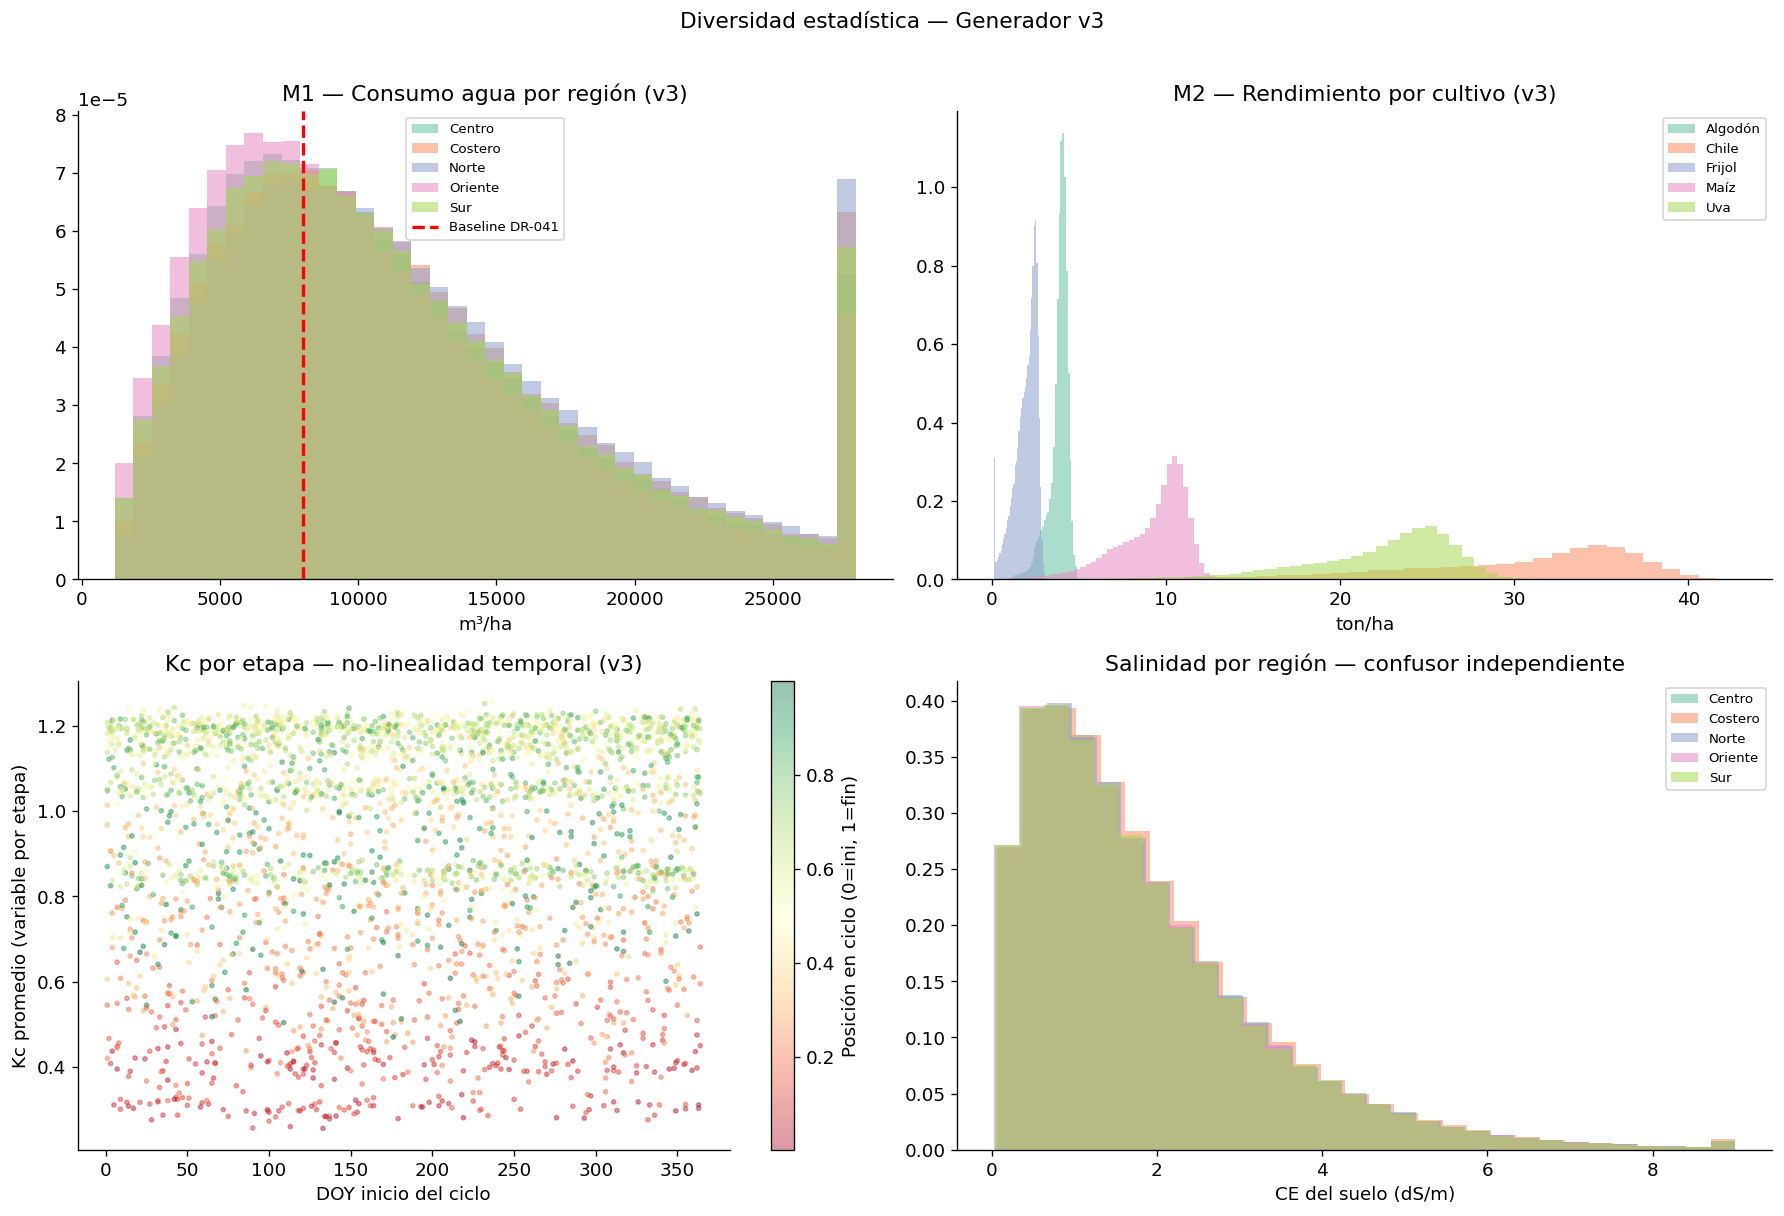


Diagnósticos completados


In [11]:
# ── Diagnósticos de diversidad estadística v3 ─────────────────────────────

from scipy import stats as sp_stats

def entropia_bins(series, n_bins=20):
    """Entropía de Shannon de una serie numérica (binned)."""
    counts, _ = np.histogram(series.dropna(), bins=n_bins)
    probs = counts[counts > 0] / counts.sum()
    return float(-np.sum(probs * np.log2(probs + 1e-12)))

def bimodality_coef(x):
    """Sarle's bimodality coefficient. b > 0.555 = multimodal."""
    n  = len(x)
    sk = sp_stats.skew(x)
    ku = sp_stats.kurtosis(x)
    return (sk**2 + 1) / (ku + 3 * (n-1)**2 / ((n-2)*(n-3)))

# 1. Estadísticas de targets por región
print("=" * 60)
print("TARGET M1 (vol. agua m³/ha) — MEDIA Y STD POR REGIÓN")
print("=" * 60)
print(df.groupby("region")["volumen_agua_total_m3_ha"].agg(
    media="mean", std="std", p10=lambda x: x.quantile(0.10),
    p90=lambda x: x.quantile(0.90)
).round(0).to_string())

print()
print("=" * 60)
print("TARGET M2 (rendimiento ton/ha) — POR CULTIVO × ARQUETIPO")
print("=" * 60)
print(df.groupby(["cultivo","tipo_agricultor"])["rendimiento_real_ton_ha"].agg(
    media="mean", std="std"
).round(3).unstack().to_string())

# 2. Entropía de features numéricas clave
print()
print("=" * 60)
print("ENTROPÍA DE SHANNON (bits) — features numéricas")
print("Más bits = más diversidad informacional")
print("=" * 60)
num_feats = ["et0_promedio_mmdia","lluvia_total_mm","kc_promedio",
             "deficit_hidrico_frac","salinidad_ec_dsm","aporte_capilar_mm",
             "volumen_agua_total_m3_ha","rendimiento_real_ton_ha"]
for feat in num_feats:
    if feat in df.columns:
        h = entropia_bins(df[feat])
        print(f"  {feat:<30s}: {h:.2f} bits")

# 3. Bimodalidad de targets
print()
print("=" * 60)
print("COEFICIENTE DE BIMODALIDAD (Sarle's b > 0.555 = multimodal)")
print("=" * 60)
for feat in ["volumen_agua_total_m3_ha","rendimiento_real_ton_ha","kc_promedio","salinidad_ec_dsm"]:
    if feat in df.columns:
        b = bimodality_coef(df[feat].dropna().values)
        flag = "⚠ MULTIMODAL" if b > 0.555 else "unimodal"
        print(f"  {feat:<35s}: b={b:.3f}  {flag}")

# 4. Tasa de eventos extremos
print()
print("=" * 60)
print("TASA DE EVENTOS EXTREMOS (% del dataset)")
print("=" * 60)
eventos = ["ola_calor","helada","inundacion","plaga","falla_riego"]
for ev in eventos:
    if ev in df.columns:
        tasa = df[ev].mean() * 100
        print(f"  {ev:<20s}: {tasa:.1f}%")

# 5. Visualización: distribuciones de target por región y arquetipo
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# M1 por región
for reg, g in df.groupby("region"):
    axes[0, 0].hist(g["volumen_agua_total_m3_ha"], bins=40,
                    alpha=0.55, label=reg, density=True)
axes[0, 0].axvline(8000, color="red", lw=2, ls="--", label="Baseline DR-041")
axes[0, 0].set_xlabel("m³/ha")
axes[0, 0].set_title("M1 — Consumo agua por región (v3)")
axes[0, 0].legend(fontsize=8)

# M2 por cultivo
for cultivo, g in df.groupby("cultivo"):
    axes[0, 1].hist(g["rendimiento_real_ton_ha"], bins=40,
                    alpha=0.55, label=cultivo, density=True)
axes[0, 1].set_xlabel("ton/ha")
axes[0, 1].set_title("M2 — Rendimiento por cultivo (v3)")
axes[0, 1].legend(fontsize=8)

# Kc por etapa vs DOY (muestra no-linealidad)
sc = axes[1, 0].scatter(df["doy_inicio"].sample(min(3000, len(df)), random_state=42),
                         df["kc_promedio"].sample(min(3000, len(df)), random_state=42),
                         c=df["pos_ciclo_frac"].sample(min(3000, len(df)), random_state=42),
                         cmap="RdYlGn", alpha=0.4, s=6)
plt.colorbar(sc, ax=axes[1, 0], label="Posición en ciclo (0=ini, 1=fin)")
axes[1, 0].set_xlabel("DOY inicio del ciclo")
axes[1, 0].set_ylabel("Kc promedio (variable por etapa)")
axes[1, 0].set_title("Kc por etapa — no-linealidad temporal (v3)")

# Salinidad por región
for reg, g in df.groupby("region"):
    axes[1, 1].hist(g["salinidad_ec_dsm"], bins=30, alpha=0.55, label=reg, density=True)
axes[1, 1].set_xlabel("CE del suelo (dS/m)")
axes[1, 1].set_title("Salinidad por región — confusor independiente")
axes[1, 1].legend(fontsize=8)

plt.suptitle("Diversidad estadística — Generador v3", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\nDiagnósticos completados")

## 2. Análisis exploratorio

In [12]:
print("Targets por cultivo:")

df.groupby("cultivo")[["volumen_agua_total_m3_ha","rendimiento_real_ton_ha"]].agg(

    ["mean","std","min","max"]).round(2)

Targets por cultivo:


volumen_agua_total_m3_ha                            \
                            mean      std     min      max   
cultivo                                                      
Algodón                 16131.80  7003.05  1200.0  28000.0   
Chile                    9301.53  4951.57  1200.0  28000.0   
Frijol                   8187.43  4493.79  1200.0  28000.0   
Maíz                    12239.97  6475.56  1200.0  28000.0   
Uva                     11612.47  6223.66  1200.0  28000.0   

        rendimiento_real_ton_ha                     
                           mean   std   min    max  
cultivo                                             
Algodón                    3.83  0.56  0.62   4.88  
Chile                     30.03  7.26  0.46  42.70  
Frijol                     1.94  0.64  0.12   3.05  
Maíz                       9.23  2.01  0.41  12.81  
Uva                       22.32  4.28  2.28  30.50

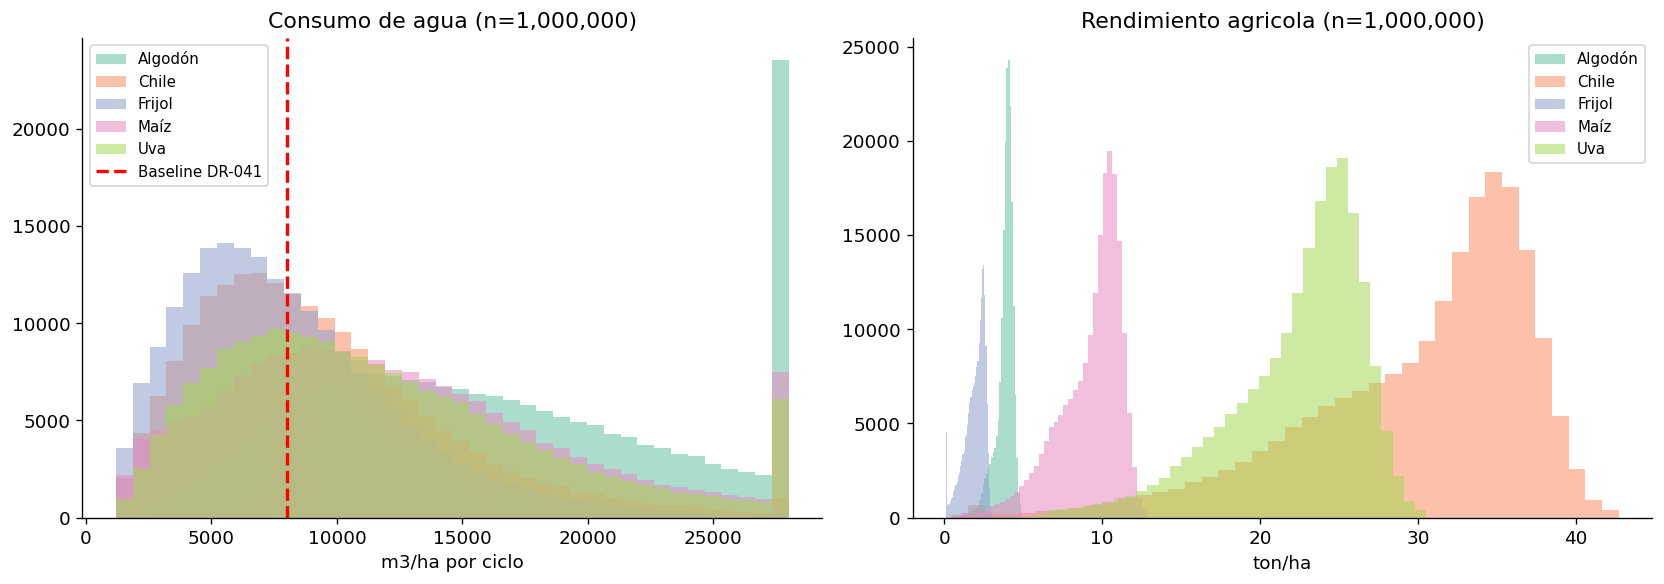

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


for cultivo, g in df.groupby("cultivo"):

    axes[0].hist(g["volumen_agua_total_m3_ha"], bins=40, alpha=0.55, label=cultivo)

axes[0].axvline(8000, color="red", lw=2, ls="--", label="Baseline DR-041")

axes[0].set_xlabel("m3/ha por ciclo")

axes[0].set_title(f"Consumo de agua (n={N_SAMPLES:,})")

axes[0].legend(fontsize=9)


for cultivo, g in df.groupby("cultivo"):

    axes[1].hist(g["rendimiento_real_ton_ha"], bins=40, alpha=0.55, label=cultivo)

axes[1].set_xlabel("ton/ha")

axes[1].set_title(f"Rendimiento agricola (n={N_SAMPLES:,})")

axes[1].legend(fontsize=9)


plt.tight_layout()

plt.show()

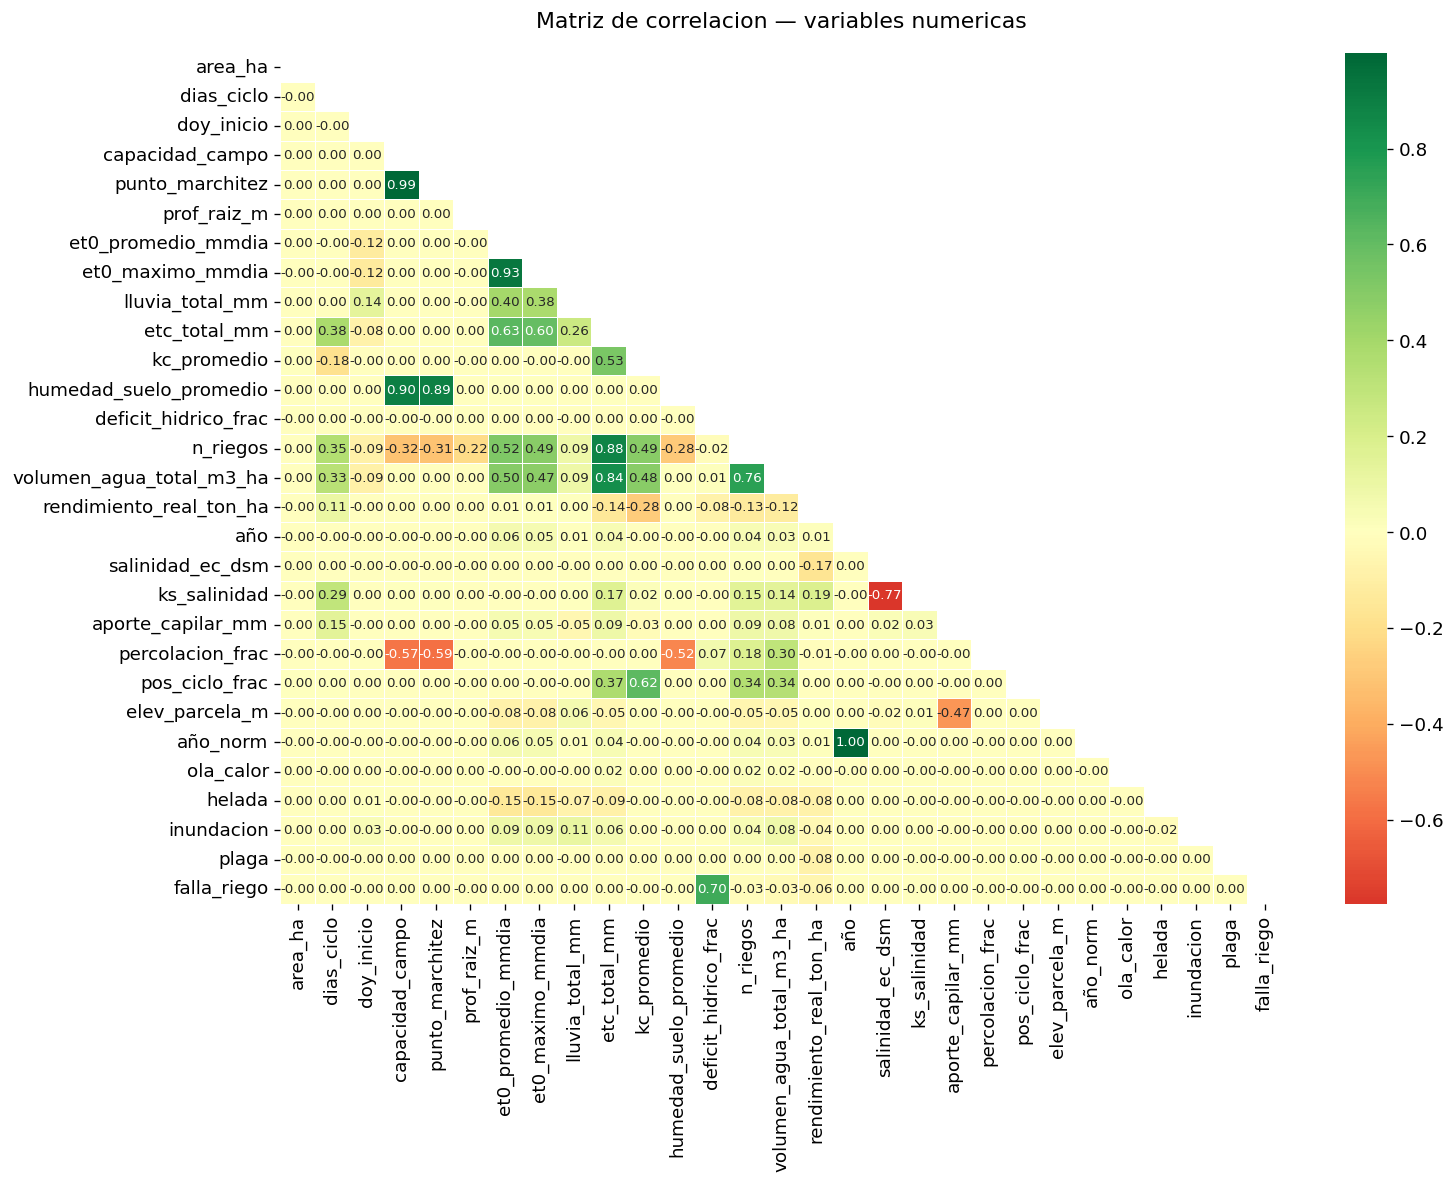

In [14]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

corr = df[num_cols].corr()


fig, ax = plt.subplots(figsize=(13, 10))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",

            center=0, linewidths=0.4, ax=ax, annot_kws={"size": 8})

ax.set_title("Matriz de correlacion — variables numericas", pad=15)

plt.tight_layout()

plt.show()

## 3. Feature Engineering


| Feature | Formula | Interpretacion |

|---------|---------|----------------|

| `eto_x_dias` | ET0_prom x dias_ciclo | Demanda evapotranspirativa total |

| `deficit_agua_mm` | ETc - lluvia (>=0) | Agua que debe reponer el riego |

| `agua_disponible_mm` | (CC-PMP) x prof x 1000 | Capacidad de retencion del suelo |

| `ky_cultivo` | lookup FAO-56 | Sensibilidad al deficit hidrico |

| `indice_estres_x_ky` | deficit_frac x Ky | Impacto potencial en rendimiento (FAO-33) |

| `doy_sin / doy_cos` | sin/cos(2*pi*DOY/365) | Estacionalidad sin discontinuidad en dia 365->1 |

| `eficiencia_sistema` | lookup 0-1 | Fraccion de agua que llega a la raiz |

| `ratio_demanda_suelo` | ETc / agua_disponible | Intensidad de riego necesaria |

In [15]:
KY_MAP = {"Maíz":1.25, "Frijol":1.15, "Algodón":0.85, "Uva":0.85, "Chile":1.10}
EF_MAP = {"gravedad":0.50, "aspersion":0.75, "goteo":0.90, "microaspersion":0.85}

# ── Features v2 (sin cambio) ─────────────────────────────────────────────────
df["eto_x_dias"]          = df["et0_promedio_mmdia"] * df["dias_ciclo"]
df["deficit_agua_mm"]     = (df["etc_total_mm"] - df["lluvia_total_mm"]).clip(lower=0)
df["agua_disponible_mm"]  = (df["capacidad_campo"] - df["punto_marchitez"]) * df["prof_raiz_m"] * 1000
df["ky_cultivo"]          = df["cultivo"].map(KY_MAP)
df["eficiencia_sistema"]  = df["sistema_riego"].map(EF_MAP)
df["indice_estres_x_ky"]  = df["deficit_hidrico_frac"] * df["ky_cultivo"]
df["doy_sin"]             = np.sin(2 * np.pi * df["doy_inicio"] / 365)
df["doy_cos"]             = np.cos(2 * np.pi * df["doy_inicio"] / 365)
df["ratio_demanda_suelo"] = (df["etc_total_mm"] / df["agua_disponible_mm"].replace(0, np.nan)).fillna(1.0)

# ── Features v3 adicionales ───────────────────────────────────────────────────
# Posición estacional del ciclo (sin/cos para continuidad 0→1)
df["ciclo_sin"] = np.sin(2 * np.pi * df["pos_ciclo_frac"]) if "pos_ciclo_frac" in df.columns else 0.0
df["ciclo_cos"] = np.cos(2 * np.pi * df["pos_ciclo_frac"]) if "pos_ciclo_frac" in df.columns else 1.0

# Interacción salinidad × estrés hídrico (sinérgico — ambos reducen rendimiento)
df["estres_combinado"] = (df["deficit_hidrico_frac"] * 
                          (1 - df.get("ks_salinidad", pd.Series(1.0, index=df.index))))

# Agua efectiva: deficit_neto considerando aporte capilar
df["deficit_neto_mm"] = (df["deficit_agua_mm"] - df.get("aporte_capilar_mm", 0.0)).clip(lower=0)

# Intensidad de riego: m³/ha por evento de riego
df["m3_por_riego"] = (df["volumen_agua_total_m3_ha"] / df["n_riegos"].replace(0, 1)).round(2)

# Flag: año reciente (proxy de mejora varietales — no estacionariedad)
if "año" in df.columns:
    df["año_norm_feat"] = df.get("año_norm", (df["año"] - df["año"].min()) / max(df["año"].max() - df["año"].min(), 1))

# Flag de evento extremo agregado (al menos 1 evento ocurrió)
event_cols = [c for c in ["ola_calor","helada","inundacion","plaga","falla_riego"] if c in df.columns]
if event_cols:
    df["evento_extremo"] = (df[event_cols].sum(axis=1) > 0).astype(np.int8)

print(f"Features derivadas creadas: {9} v2 + {len([c for c in ['ciclo_sin','ciclo_cos','estres_combinado','deficit_neto_mm','m3_por_riego','año_norm_feat','evento_extremo'] if c in df.columns])} v3")

Features derivadas creadas: 9 v2 + 7 v3


## 4. Preparacion ML

In [16]:
# Codificar todas las variables categóricas
cat_cols = ["cultivo", "tipo_suelo", "sistema_riego"]
# Añadir columnas categóricas nuevas v3 si existen
for col_v3 in ["region", "tipo_agricultor"]:
    if col_v3 in df.columns:
        cat_cols.append(col_v3)

le_dict  = {}
df_enc   = df.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

cultivo: {'Algodón': np.int64(0), 'Chile': np.int64(1), 'Frijol': np.int64(2), 'Maíz': np.int64(3), 'Uva': np.int64(4)}
tipo_suelo: {'arcilloso': np.int64(0), 'franco': np.int64(1), 'franco-arcilloso': np.int64(2), 'franco-arenoso': np.int64(3)}
sistema_riego: {'aspersion': np.int64(0), 'goteo': np.int64(1), 'gravedad': np.int64(2), 'microaspersion': np.int64(3)}
region: {'Centro': np.int64(0), 'Costero': np.int64(1), 'Norte': np.int64(2), 'Oriente': np.int64(3), 'Sur': np.int64(4)}
tipo_agricultor: {'conservador': np.int64(0), 'eficiente': np.int64(1), 'negligente': np.int64(2), 'tecnificado': np.int64(3)}


In [17]:
# ── M1: Consumo de agua ─────────────────────────────────────────────────────
FEATURES_AGUA = [
    # Categóricas base
    "cultivo", "tipo_suelo", "sistema_riego",
    # Nuevas categóricas v3
    *(["region", "tipo_agricultor"] if "region" in df_enc.columns else []),
    # Numéricas base
    "area_ha", "dias_ciclo", "doy_inicio", "doy_sin", "doy_cos",
    "capacidad_campo", "punto_marchitez", "prof_raiz_m",
    "et0_promedio_mmdia", "et0_maximo_mmdia", "lluvia_total_mm",
    "etc_total_mm", "kc_promedio", "n_riegos",
    # Features derivadas v2
    "eto_x_dias", "deficit_agua_mm", "agua_disponible_mm",
    "eficiencia_sistema", "ratio_demanda_suelo",
    # Features v3 (solo si existen en df_enc)
    *(["salinidad_ec_dsm"]    if "salinidad_ec_dsm"    in df_enc.columns else []),
    *(["aporte_capilar_mm"]   if "aporte_capilar_mm"   in df_enc.columns else []),
    *(["percolacion_frac"]    if "percolacion_frac"     in df_enc.columns else []),
    *(["pos_ciclo_frac"]      if "pos_ciclo_frac"       in df_enc.columns else []),
    *(["ciclo_sin"]           if "ciclo_sin"            in df_enc.columns else []),
    *(["ciclo_cos"]           if "ciclo_cos"            in df_enc.columns else []),
    *(["elev_parcela_m"]      if "elev_parcela_m"       in df_enc.columns else []),
    *(["año_norm_feat"]       if "año_norm_feat"        in df_enc.columns else []),
    *(["deficit_neto_mm"]     if "deficit_neto_mm"      in df_enc.columns else []),
    *(["ola_calor"]           if "ola_calor"            in df_enc.columns else []),
    *(["inundacion"]          if "inundacion"           in df_enc.columns else []),
    *(["falla_riego"]         if "falla_riego"          in df_enc.columns else []),
    *(["evento_extremo"]      if "evento_extremo"       in df_enc.columns else []),
]

# ── M2: Rendimiento ──────────────────────────────────────────────────────────
FEATURES_REND = [
    # Categóricas base
    "cultivo", "tipo_suelo", "sistema_riego",
    # Nuevas categóricas v3
    *(["region", "tipo_agricultor"] if "region" in df_enc.columns else []),
    # Numéricas base
    "area_ha", "dias_ciclo", "doy_inicio", "doy_sin", "doy_cos",
    "capacidad_campo", "punto_marchitez", "prof_raiz_m",
    "et0_promedio_mmdia", "et0_maximo_mmdia", "lluvia_total_mm",
    "etc_total_mm", "kc_promedio",
    "humedad_suelo_promedio", "deficit_hidrico_frac", "n_riegos",
    # Features derivadas v2
    "eto_x_dias", "deficit_agua_mm", "agua_disponible_mm",
    "ky_cultivo", "indice_estres_x_ky", "ratio_demanda_suelo",
    # Features v3
    *(["salinidad_ec_dsm"]    if "salinidad_ec_dsm"    in df_enc.columns else []),
    *(["ks_salinidad"]        if "ks_salinidad"         in df_enc.columns else []),
    *(["aporte_capilar_mm"]   if "aporte_capilar_mm"   in df_enc.columns else []),
    *(["pos_ciclo_frac"]      if "pos_ciclo_frac"       in df_enc.columns else []),
    *(["ciclo_sin"]           if "ciclo_sin"            in df_enc.columns else []),
    *(["ciclo_cos"]           if "ciclo_cos"            in df_enc.columns else []),
    *(["año_norm_feat"]       if "año_norm_feat"        in df_enc.columns else []),
    *(["estres_combinado"]    if "estres_combinado"     in df_enc.columns else []),
    *(["elev_parcela_m"]      if "elev_parcela_m"       in df_enc.columns else []),
    *(["ola_calor"]           if "ola_calor"            in df_enc.columns else []),
    *(["helada"]              if "helada"               in df_enc.columns else []),
    *(["inundacion"]          if "inundacion"           in df_enc.columns else []),
    *(["plaga"]               if "plaga"                in df_enc.columns else []),
    *(["falla_riego"]         if "falla_riego"          in df_enc.columns else []),
    *(["evento_extremo"]      if "evento_extremo"       in df_enc.columns else []),
]

TARGET_AGUA = "volumen_agua_total_m3_ha"
TARGET_REND = "rendimiento_real_ton_ha"

X_agua = df_enc[FEATURES_AGUA]; y_agua = df_enc[TARGET_AGUA]
X_rend = df_enc[FEATURES_REND]; y_rend = df_enc[TARGET_REND]

X_agua_tr, X_agua_te, y_agua_tr, y_agua_te = train_test_split(
    X_agua, y_agua, test_size=0.20, random_state=SEED, stratify=df_enc["cultivo"])
X_rend_tr, X_rend_te, y_rend_tr, y_rend_te = train_test_split(
    X_rend, y_rend, test_size=0.20, random_state=SEED, stratify=df_enc["cultivo"])

print(f"Train: {X_agua_tr.shape[0]:,} | Test: {X_agua_te.shape[0]:,}")
print(f"Features M1: {len(FEATURES_AGUA)} | Features M2: {len(FEATURES_REND)}")

Train: 800,000 | Test: 200,000
Features M1: 37 | Features M2: 42


## 5. Visualizacion SHAP (XGBoost nativo, sin paquete shap)


XGBoost 2.x/3.x calcula valores SHAP directamente con `predict(pred_contribs=True)`.

El ultimo elemento de cada fila es el bias — se descarta.

La visualizacion se hace con matplotlib puro (beeswarm ordenado por importancia media).

In [18]:
def plot_shap_summary(shap_vals, X, feature_names, title="SHAP Summary", top_n=15, color="#5b8db8"):
    """
    Beeswarm SHAP plot usando matplotlib puro.
    No requiere el paquete shap — usa solo numpy y matplotlib.
    """
    mean_abs = np.abs(shap_vals).mean(axis=0)
    order    = np.argsort(mean_abs)[-top_n:]

    shap_sel  = shap_vals[:, order]
    feat_sel  = np.array(feature_names)[order]
    # Siempre usar .values si X es DataFrame para evitar indexing ambiguo
    X_arr = X.values if hasattr(X, 'values') else np.asarray(X)
    feat_vals = X_arr[:, order].astype(float)

    # Normalizar valores de feature a [0,1] para colorear por magnitud
    feat_norm = feat_vals.copy()
    for j in range(feat_norm.shape[1]):
        col = feat_norm[:, j]
        rng = col.max() - col.min()
        feat_norm[:, j] = (col - col.min()) / rng if rng > 0 else 0.5

    fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.45)))
    cmap = plt.cm.RdYlBu_r

    for idx in range(shap_sel.shape[1]):
        y_jitter = idx + np.random.uniform(-0.3, 0.3, len(shap_sel))
        ax.scatter(shap_sel[:, idx], y_jitter,
                   c=feat_norm[:, idx], cmap=cmap,
                   alpha=0.25, s=8, linewidths=0)

    ax.set_yticks(range(len(feat_sel)))
    ax.set_yticklabels(feat_sel, fontsize=10)
    ax.axvline(0, color="gray", lw=0.8, ls="--")
    ax.set_xlabel("Valor SHAP (impacto en prediccion)")
    ax.set_title(title)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Valor del feature (bajo → alto)", fontsize=9)

    plt.tight_layout()
    plt.show()


def get_shap_vals(model, X, feature_names):
    """
    Extrae SHAP values via XGBoost nativo pred_contribs=True.

    FIX CRÍTICO: usa iteration_range=(0, best_iteration+1) para que los
    SHAP values correspondan EXACTAMENTE al mismo modelo que usa model.predict().
    Sin esto, con early stopping el booster usa TODOS los árboles (incluyendo
    los overfitted) mientras predict() usa solo los mejores → valores SHAP
    incoherentes con las predicciones reales.
    """
    # Extraer best_iteration si el modelo usa early stopping
    best_iter = getattr(model, 'best_iteration', None)
    iter_range = (0, best_iter + 1) if best_iter is not None and best_iter > 0 else None

    # Convertir X a numpy antes de crear DMatrix (evita ambigüedad con DataFrames)
    X_arr = X.values if hasattr(X, 'values') else np.asarray(X)
    dmat  = xgb.DMatrix(X_arr, feature_names=feature_names)

    if iter_range is not None:
        raw = model.get_booster().predict(dmat, pred_contribs=True, iteration_range=iter_range)
    else:
        raw = model.get_booster().predict(dmat, pred_contribs=True)

    return raw[:, :-1]   # descartar bias (ultima columna)


def verificar_shap(model, X, feature_names, nombre="modelo", tol_rel=0.05):
    """
    Sanity check: SHAP values + bias ≈ model.predict().
    Si el error relativo medio > tol_rel (5%), hay un bug en iteration_range.
    """
    shap_vals = get_shap_vals(model, X, feature_names)
    X_arr     = X.values if hasattr(X, 'values') else np.asarray(X)
    dmat      = xgb.DMatrix(X_arr, feature_names=feature_names)

    best_iter = getattr(model, 'best_iteration', None)
    iter_range = (0, best_iter + 1) if best_iter is not None and best_iter > 0 else None

    if iter_range is not None:
        raw = model.get_booster().predict(dmat, pred_contribs=True, iteration_range=iter_range)
    else:
        raw = model.get_booster().predict(dmat, pred_contribs=True)

    shap_sum   = raw.sum(axis=1)          # SHAP features + bias
    pred_model = model.predict(X)
    max_diff   = np.abs(shap_sum - pred_model).max()
    rel_err    = max_diff / (np.abs(pred_model).mean() + 1e-8)

    status = "OK" if rel_err < tol_rel else "FALLO — iteration_range incorrecto"
    print(f"  Verificacion SHAP [{nombre}]: max_diff={max_diff:.4f} | err_rel={rel_err:.4%} | {status}")
    return rel_err < tol_rel


print("Funciones SHAP listas (XGBoost nativo, iteration_range corregido)")
print("  - get_shap_vals: usa best_iteration para coherencia con predict()")
print("  - plot_shap_summary: robusto a DataFrame/numpy")
print("  - verificar_shap: sanity check SHAP sum ≈ model.predict()")

Funciones SHAP listas (XGBoost nativo, iteration_range corregido)
  - get_shap_vals: usa best_iteration para coherencia con predict()
  - plot_shap_summary: robusto a DataFrame/numpy
  - verificar_shap: sanity check SHAP sum ≈ model.predict()


## 6. Modelo 1 — Consumo de Agua


XGBoost construye un ensamble aditivo de arboles con regularizacion L1/L2.

**Early stopping**: detiene el entrenamiento cuando el RMSE de validacion

no mejora en 50 rondas consecutivas — no es necesario tunear `n_estimators` a mano.

In [19]:
def metricas(y_true, y_pred, nombre, tarifa=1.68):

    mae  = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2   = r2_score(y_true, y_pred)

    print(f"{'─'*52}")

    print(f"  {nombre}")

    print(f"  MAE   = {mae:>10.2f}")

    print(f"  RMSE  = {rmse:>10.2f}")

    print(f"  R2    = {r2:>10.4f}")

    if "agua" in nombre.lower():

        print(f"  Error monetario = ${rmse*tarifa:,.0f} MXN/ha/ciclo")

    print(f"{'─'*52}")

    return {"mae":mae, "rmse":rmse, "r2":r2}

In [20]:
X_agua_tr2, X_agua_val, y_agua_tr2, y_agua_val = train_test_split(

    X_agua_tr, y_agua_tr, test_size=0.10, random_state=SEED)


params_agua = dict(

    n_estimators=2000, max_depth=5, learning_rate=0.05,

    subsample=0.80, colsample_bytree=0.80, min_child_weight=3,

    reg_alpha=0.10, reg_lambda=1.00,

    early_stopping_rounds=50, eval_metric="rmse",

    random_state=SEED, n_jobs=-1, verbosity=0,

)


t0 = time.time()

model_agua = xgb.XGBRegressor(**params_agua)

model_agua.fit(X_agua_tr2, y_agua_tr2,

               eval_set=[(X_agua_val, y_agua_val)], verbose=False)

elapsed = time.time() - t0


pred_agua = model_agua.predict(X_agua_te)

met_agua  = metricas(y_agua_te, pred_agua, "M1 — Consumo de agua (m3/ha)")

print(f"Entrenamiento: {elapsed:.1f}s | Best iter: {model_agua.best_iteration}")

────────────────────────────────────────────────────
  M1 — Consumo de agua (m3/ha)
  MAE   =     905.76
  RMSE  =    1335.11
  R2    =     0.9579
  Error monetario = $2,243 MXN/ha/ciclo
────────────────────────────────────────────────────
Entrenamiento: 41.8s | Best iter: 320


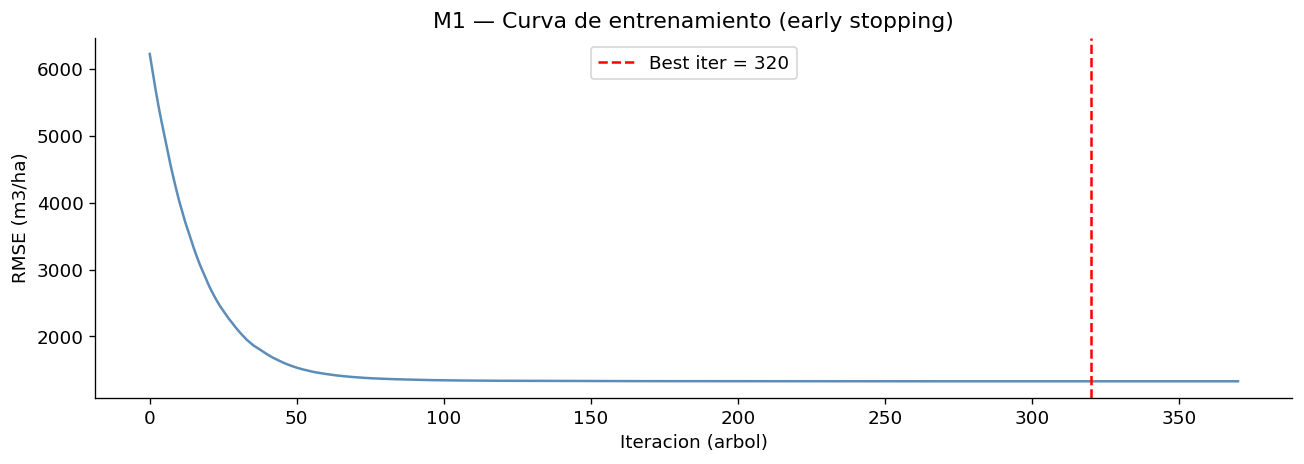

In [21]:
# Curva de entrenamiento (loss por iteracion)

evals_agua = model_agua.evals_result().get("validation_0", {}).get("rmse", [])


if evals_agua:

    fig, ax = plt.subplots(figsize=(11, 4))

    ax.plot(evals_agua, color="#5b8db8", lw=1.5)

    ax.axvline(model_agua.best_iteration, color="red", ls="--", lw=1.5,

               label=f"Best iter = {model_agua.best_iteration}")

    ax.set_xlabel("Iteracion (arbol)")

    ax.set_ylabel("RMSE (m3/ha)")

    ax.set_title("M1 — Curva de entrenamiento (early stopping)")

    ax.legend()

    plt.tight_layout()

    plt.show()

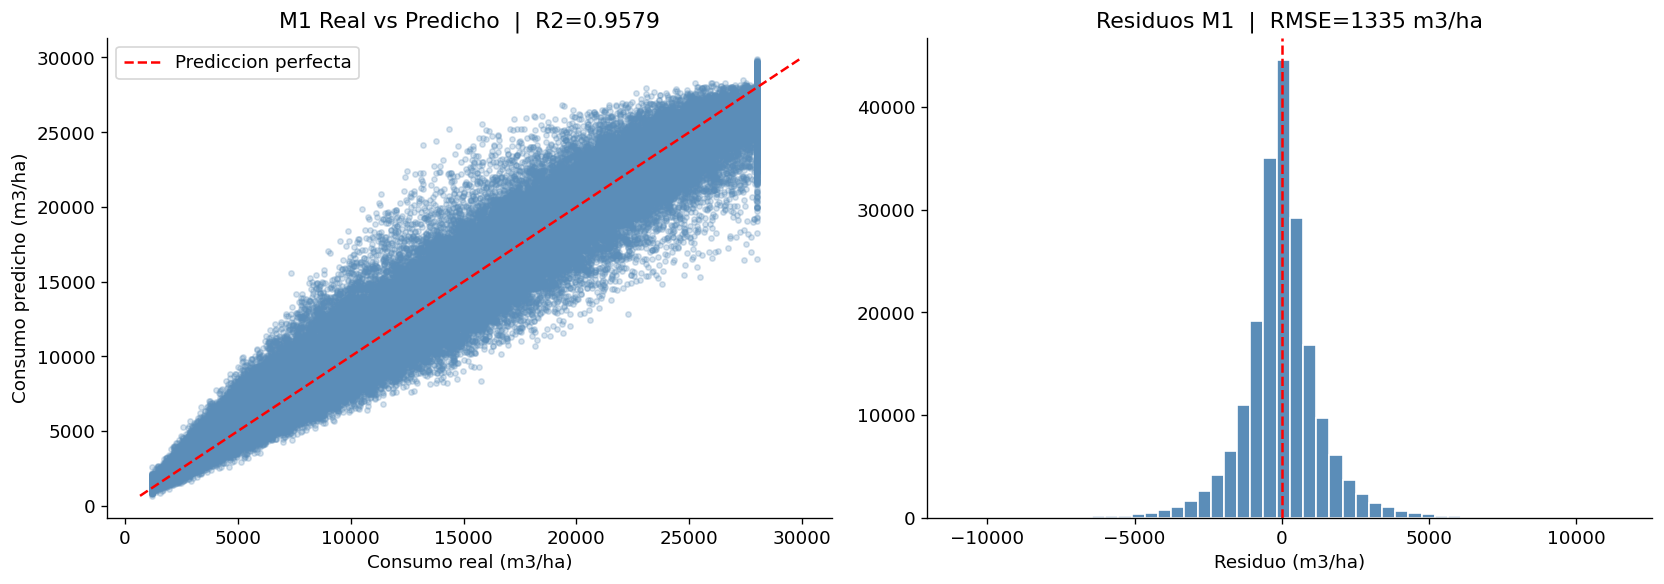


Sesgo por rango de consumo:
                          n  error_medio (m3/ha)    RMSE
bin                                                     
(1173.2, 6560.0]    50261.0                199.0   691.0
(6560.0, 11920.0]   70726.0                146.0  1131.0
(11920.0, 17280.0]  42796.0                 -3.0  1577.0
(17280.0, 22640.0]  20310.0               -252.0  1938.0
(22640.0, 28000.0]  15907.0               -886.0  1932.0


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Real vs Predicho

axes[0].scatter(y_agua_te, pred_agua, alpha=0.25, s=10, color="#5b8db8")

lims = [min(y_agua_te.min(), pred_agua.min()), max(y_agua_te.max(), pred_agua.max())]

axes[0].plot(lims, lims, "r--", lw=1.5, label="Prediccion perfecta")

axes[0].set_xlabel("Consumo real (m3/ha)")

axes[0].set_ylabel("Consumo predicho (m3/ha)")

axes[0].set_title(f"M1 Real vs Predicho  |  R2={met_agua['r2']:.4f}")

axes[0].legend()


# Distribucion de residuos

res = y_agua_te.values - pred_agua

axes[1].hist(res, bins=50, color="#5b8db8", edgecolor="white")

axes[1].axvline(0, color="red", lw=1.5, ls="--")

axes[1].set_xlabel("Residuo (m3/ha)")

axes[1].set_title(f"Residuos M1  |  RMSE={met_agua['rmse']:.0f} m3/ha")


plt.tight_layout()

plt.show()


# Sesgo por rango

bins_real = pd.cut(y_agua_te, bins=5)

sesgo = pd.DataFrame({"real":y_agua_te, "pred":pred_agua, "bin":bins_real})

print("\nSesgo por rango de consumo:")

print(sesgo.groupby("bin", observed=True).apply(

    lambda g: pd.Series({

        "n": len(g),

        "error_medio (m3/ha)": round((g["pred"]-g["real"]).mean(), 0),

        "RMSE": round(np.sqrt(mean_squared_error(g["real"],g["pred"])), 0)

    })

))

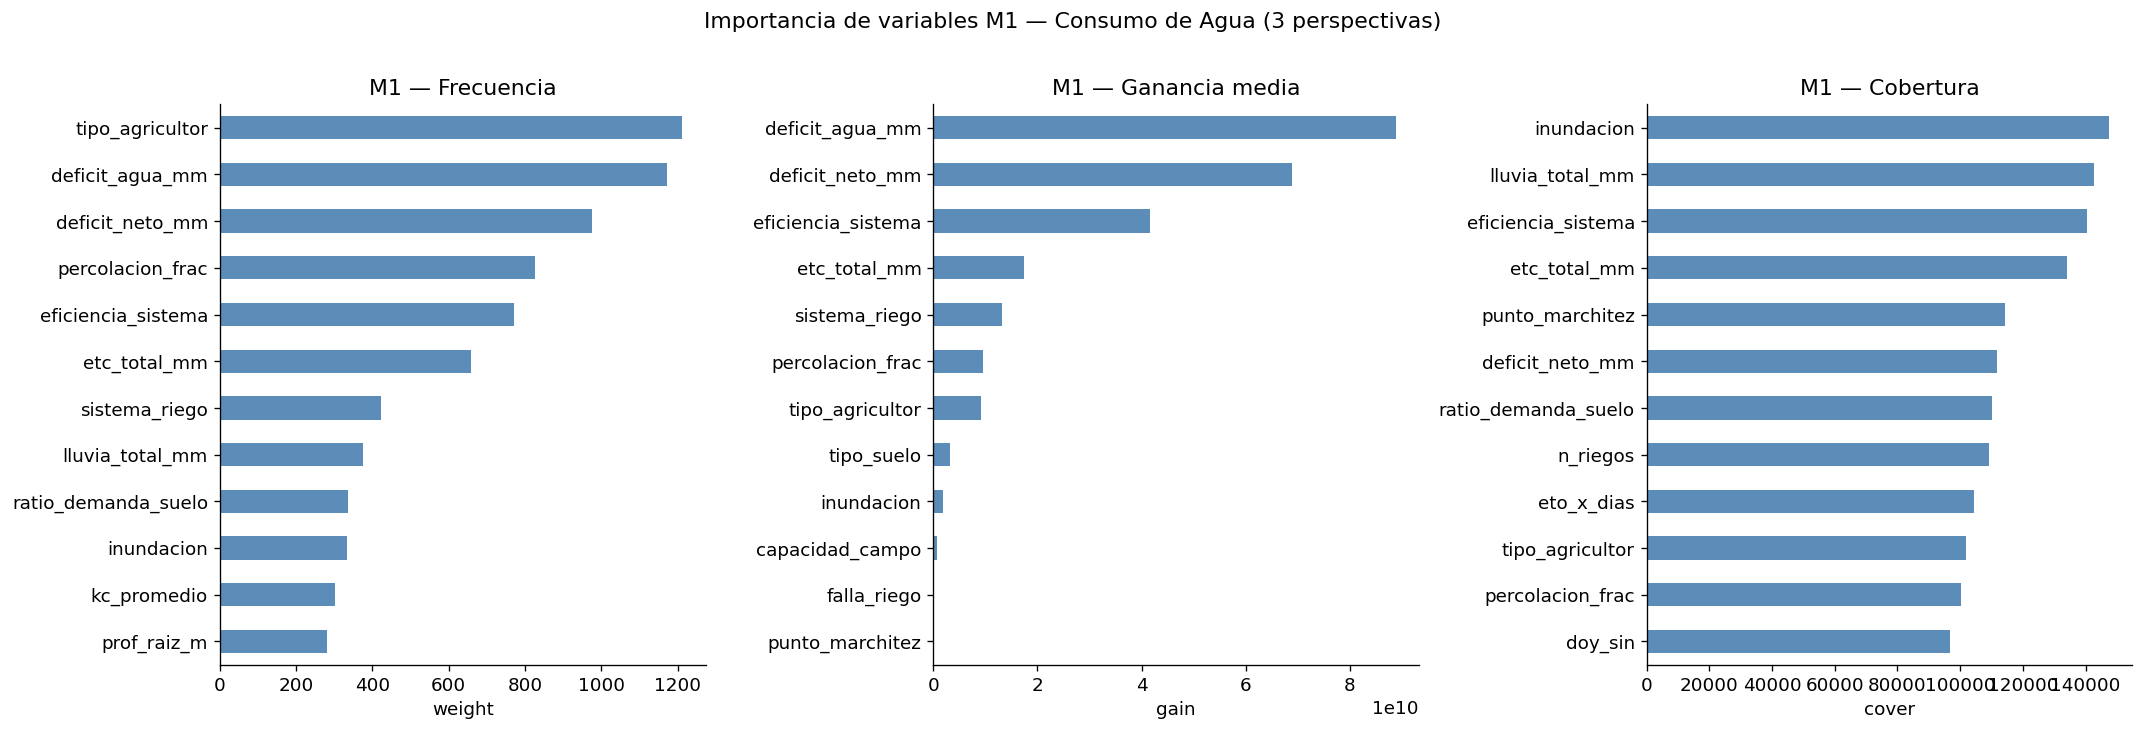

In [23]:
# Importancia de variables — 3 perspectivas XGBoost

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

imp_types = [("weight","Frecuencia"), ("gain","Ganancia media"), ("cover","Cobertura")]


for ax, (itype, ilabel) in zip(axes, imp_types):

    scores = model_agua.get_booster().get_score(importance_type=itype)

    series = pd.Series(scores).sort_values(ascending=True).tail(12)

    series.plot(kind="barh", ax=ax, color="#5b8db8")

    ax.set_title(f"M1 — {ilabel}")

    ax.set_xlabel(itype)


plt.suptitle("Importancia de variables M1 — Consumo de Agua (3 perspectivas)", y=1.01)

plt.tight_layout()

plt.show()

  Verificacion SHAP [M1 Agua]: max_diff=0.0410 | err_rel=0.0004% | OK


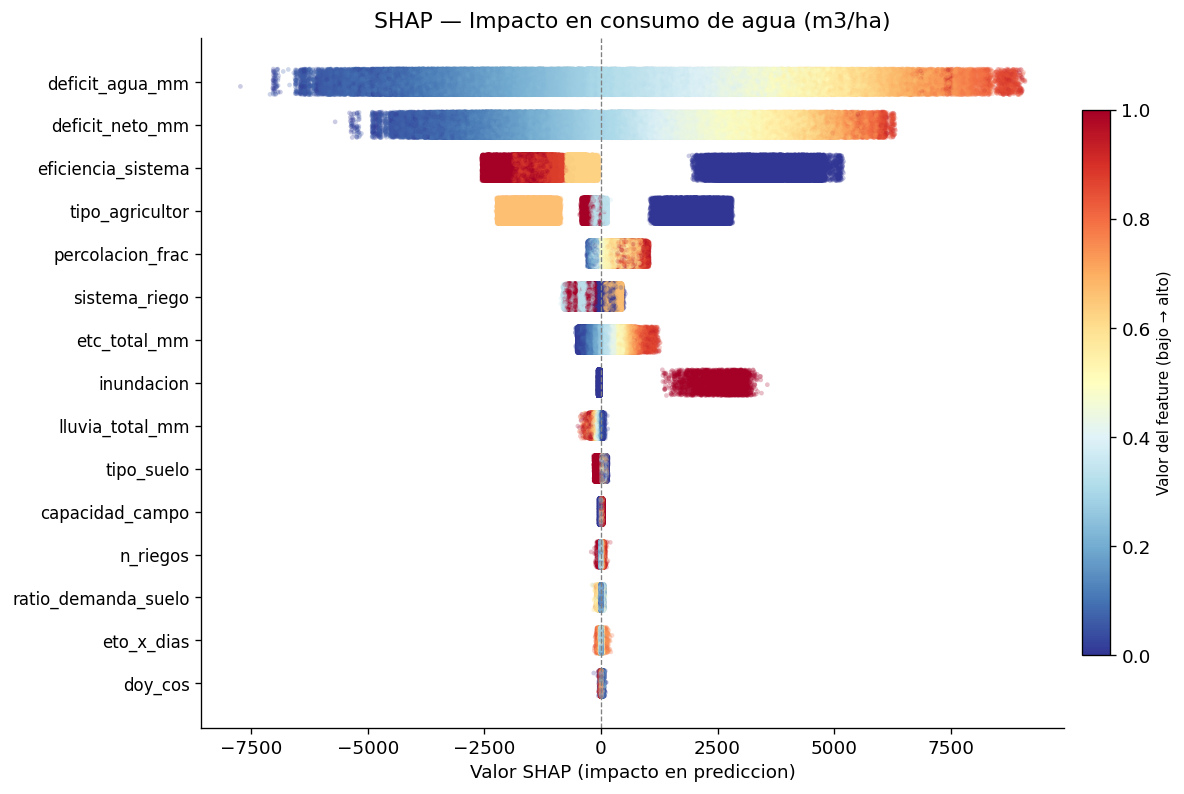

In [24]:
# SHAP summary M1 — XGBoost nativo, iteration_range corregido
shap_agua = get_shap_vals(model_agua, X_agua_te, FEATURES_AGUA)
verificar_shap(model_agua, X_agua_te, FEATURES_AGUA, nombre="M1 Agua")

plot_shap_summary(
    shap_agua,
    X_agua_te,
    FEATURES_AGUA,
    title="SHAP — Impacto en consumo de agua (m3/ha)",
    top_n=15,
)

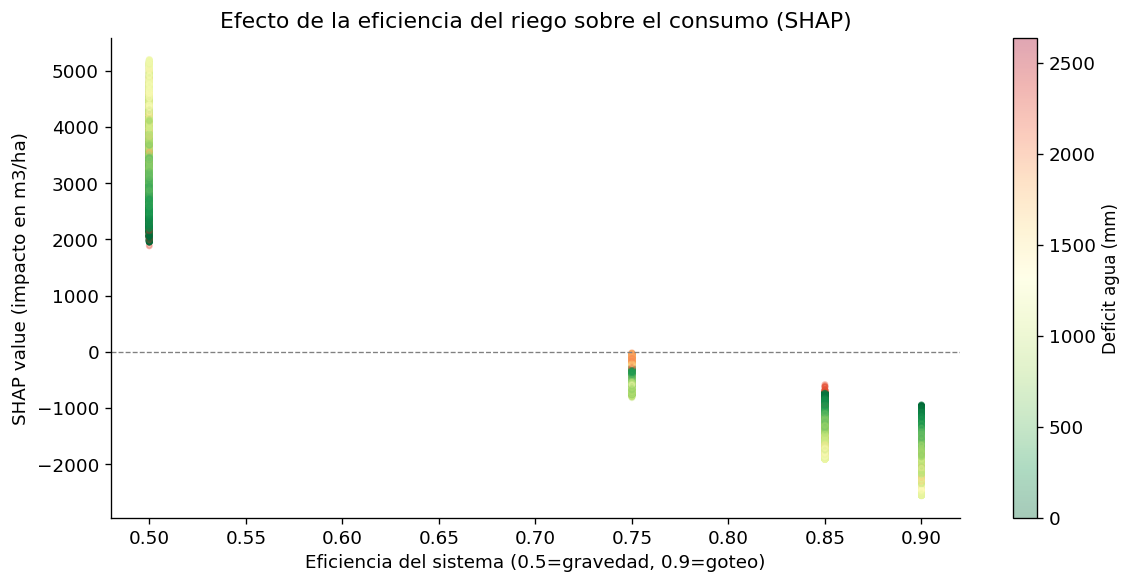

In [25]:
# SHAP dependence: eficiencia del sistema vs consumo de agua
idx_ef  = FEATURES_AGUA.index("eficiencia_sistema")
idx_def = FEATURES_AGUA.index("deficit_agua_mm")

X_agua_te_arr = X_agua_te.values  # numpy para indexing limpio

fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(
    X_agua_te_arr[:, idx_ef],
    shap_agua[:, idx_ef],
    c=X_agua_te_arr[:, idx_def],
    cmap="RdYlGn_r", alpha=0.35, s=10,
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Deficit agua (mm)", fontsize=10)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Eficiencia del sistema (0.5=gravedad, 0.9=goteo)")
ax.set_ylabel("SHAP value (impacto en m3/ha)")
ax.set_title("Efecto de la eficiencia del riego sobre el consumo (SHAP)")
plt.tight_layout()
plt.show()

## 7. Curvas de aprendizaje — cuantos datos necesitamos realmente?


Responde empiricamente si 300k o 1M filas aportan valor.

Si la curva aplana antes de N_SAMPLES, mas datos del mismo generador no mejoran el modelo.

La solucion en ese caso: mas variabilidad en el generador o datos reales de campo.

In [26]:
print("Calculando curvas de aprendizaje (puede tomar ~1-2 min)...")


lc_params = dict(

    n_estimators=200, max_depth=5, learning_rate=0.05,

    subsample=0.80, colsample_bytree=0.80,

    random_state=SEED, n_jobs=-1, verbosity=0,

)


train_sizes, train_scores, val_scores = learning_curve(

    xgb.XGBRegressor(**lc_params),

    X_agua, y_agua,

    train_sizes=np.logspace(np.log10(0.005), 0, 12),

    cv=3,

    scoring="neg_root_mean_squared_error",

    n_jobs=-1,

    random_state=SEED,

)


tr_rmse  = -train_scores.mean(axis=1)

val_rmse = -val_scores.mean(axis=1)

val_std  = val_scores.std(axis=1)


fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(train_sizes, tr_rmse,  "o-", color="#e07b54", label="Train RMSE")

ax.plot(train_sizes, val_rmse, "o-", color="#5b8db8", label="Validation RMSE")

ax.fill_between(train_sizes, val_rmse-val_std, val_rmse+val_std, alpha=0.15, color="#5b8db8")

ax.set_xlabel("Tamano del entrenamiento")

ax.set_ylabel("RMSE (m3/ha)")

ax.set_title("Curva de aprendizaje — M1 Consumo de agua")

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))

ax.legend()

plt.tight_layout()

plt.show()


print(f"RMSE con  5% ({train_sizes[2]:,.0f} muestras): {val_rmse[2]:.1f} m3/ha")

print(f"RMSE con 50% ({train_sizes[-3]:,.0f} muestras): {val_rmse[-3]:.1f} m3/ha")

print(f"RMSE con 100% ({train_sizes[-1]:,.0f} muestras): {val_rmse[-1]:.1f} m3/ha")

Calculando curvas de aprendizaje (puede tomar ~1-2 min)...


KeyboardInterrupt: 

## 8. Modelo 2 — Rendimiento Agricola


Base agronomica FAO-33: XGBoost aprende la relacion no-lineal rendimiento/estres hidrico

junto con efectos de suelo, clima y sistema de riego sin programarla explicitamente.

El feature `indice_estres_x_ky` actua como ancla hacia la solucion FAO-33.

In [ ]:
X_rend_tr2, X_rend_val, y_rend_tr2, y_rend_val = train_test_split(

    X_rend_tr, y_rend_tr, test_size=0.10, random_state=SEED)


params_rend = dict(

    n_estimators=2000, max_depth=4, learning_rate=0.04,

    subsample=0.80, colsample_bytree=0.75, min_child_weight=5,

    reg_alpha=0.05, reg_lambda=1.50,

    early_stopping_rounds=50, eval_metric="rmse",

    random_state=SEED, n_jobs=-1, verbosity=0,

)


t0 = time.time()

model_rend = xgb.XGBRegressor(**params_rend)

model_rend.fit(X_rend_tr2, y_rend_tr2,

               eval_set=[(X_rend_val, y_rend_val)], verbose=False)

elapsed = time.time() - t0


pred_rend = model_rend.predict(X_rend_te)

met_rend  = metricas(y_rend_te, pred_rend, "M2 — Rendimiento agricola (ton/ha)")

print(f"Entrenamiento: {elapsed:.1f}s | Best iter: {model_rend.best_iteration}")

────────────────────────────────────────────────────
  M2 — Rendimiento agricola (ton/ha)
  MAE   =       0.84
  RMSE  =       1.39
  R2    =     0.9856
────────────────────────────────────────────────────
Entrenamiento: 131.4s | Best iter: 1990


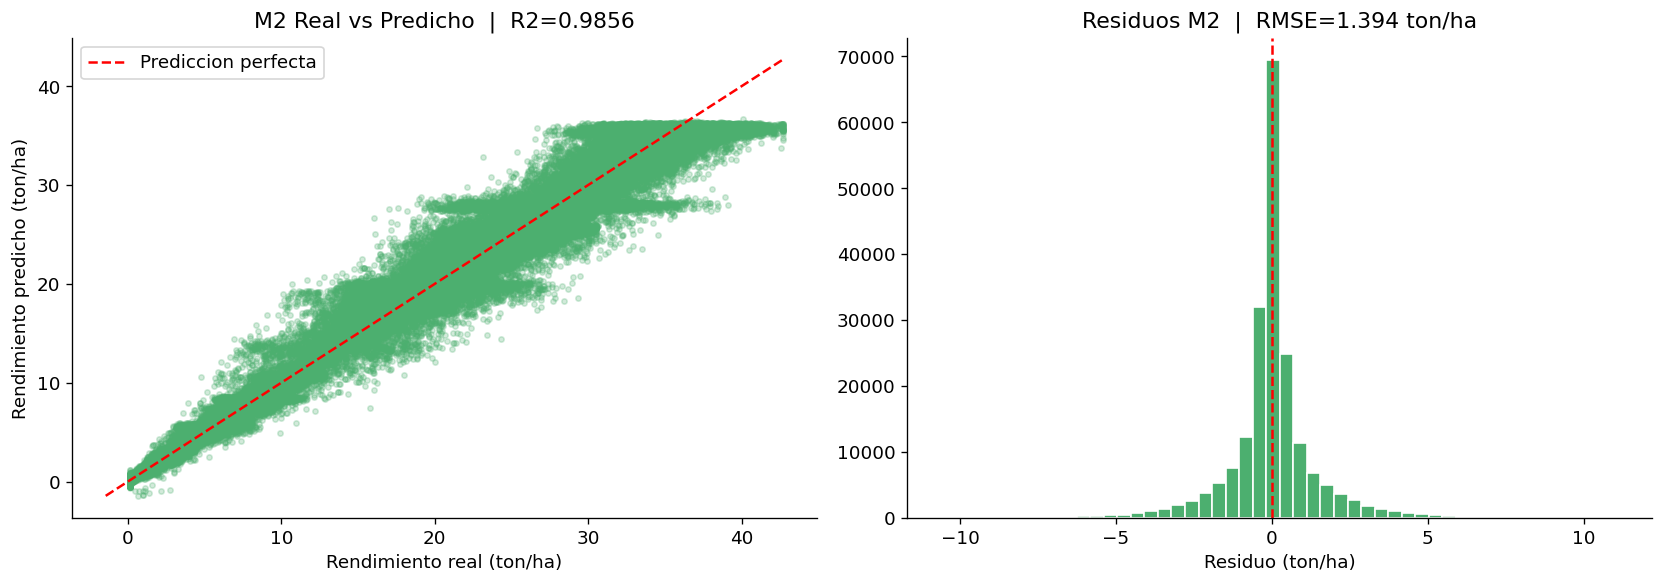

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(y_rend_te, pred_rend, alpha=0.25, s=10, color="#4caf6f")

lims = [min(y_rend_te.min(), pred_rend.min()), max(y_rend_te.max(), pred_rend.max())]

axes[0].plot(lims, lims, "r--", lw=1.5, label="Prediccion perfecta")

axes[0].set_xlabel("Rendimiento real (ton/ha)")

axes[0].set_ylabel("Rendimiento predicho (ton/ha)")

axes[0].set_title(f"M2 Real vs Predicho  |  R2={met_rend['r2']:.4f}")

axes[0].legend()


res_r = y_rend_te.values - pred_rend

axes[1].hist(res_r, bins=50, color="#4caf6f", edgecolor="white")

axes[1].axvline(0, color="red", lw=1.5, ls="--")

axes[1].set_xlabel("Residuo (ton/ha)")

axes[1].set_title(f"Residuos M2  |  RMSE={met_rend['rmse']:.3f} ton/ha")


plt.tight_layout()

plt.show()

In [ ]:
plot_shap_summary( shap_rend, X_rend_te, FEATURES_REND, title="SHAP — Impacto en rendimiento agricola (ton/ha)", top_n=15, color="#4caf6f", )

NameError: name 'X_rend_te' is not defined

NameError: name 'shap_rend' is not defined

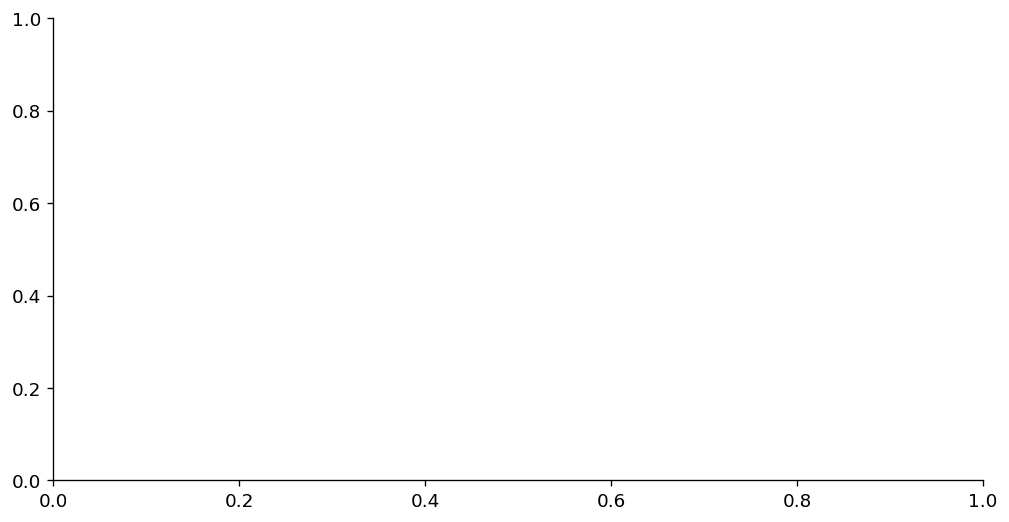

In [27]:
# SHAP dependence M2: estres hidrico x Ky vs rendimiento
idx_estres  = FEATURES_REND.index("indice_estres_x_ky")
idx_deficit = FEATURES_REND.index("deficit_hidrico_frac")

X_rend_te_arr = X_rend_te.values

fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(
    X_rend_te_arr[:, idx_estres],
    shap_rend[:, idx_estres],
    c=X_rend_te_arr[:, idx_deficit],
    cmap="RdYlGn_r", alpha=0.35, s=10,
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Deficit hidrico fraccionado", fontsize=10)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Indice estres x Ky")
ax.set_ylabel("SHAP value (impacto en ton/ha)")
ax.set_title("Efecto del estres hidrico x Ky sobre el rendimiento (SHAP)")
plt.tight_layout()
plt.show()

## 9. [OPCIONAL] Optimizacion de hiperparametros con Optuna


Requiere: `pip install optuna`

Descomenta la celda para ejecutar busqueda bayesiana (~50 trials, ~5-10 min).

In [ ]:
 try:

     import optuna

     optuna.logging.set_verbosity(optuna.logging.WARNING)



     N_HPO = min(20_000, len(X_agua_tr2))

     idx   = np.random.choice(len(X_agua_tr2), N_HPO, replace=False)

     X_hpo, y_hpo = X_agua_tr2.iloc[idx], y_agua_tr2.iloc[idx]



     def objective(trial):

         p = {

             "n_estimators":     500,

             "max_depth":        trial.suggest_int("max_depth", 3, 8),

             "learning_rate":    trial.suggest_float("lr", 0.01, 0.2, log=True),

             "subsample":        trial.suggest_float("subsample", 0.6, 1.0),

             "colsample_bytree": trial.suggest_float("colsample", 0.5, 1.0),

             "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),

             "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10, log=True),

             "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10, log=True),

             "random_state": SEED, "n_jobs": -1, "verbosity": 0,

         }

         m = xgb.XGBRegressor(**p)

         m.fit(X_hpo, y_hpo, eval_set=[(X_agua_val, y_agua_val)],

               early_stopping_rounds=30, verbose=False)

         return np.sqrt(mean_squared_error(y_agua_val, m.predict(X_agua_val)))



     study = optuna.create_study(direction="minimize")

     study.optimize(objective, n_trials=50, show_progress_bar=True)

     print("Mejores params:", study.best_params)

     print(f"RMSE: {study.best_value:.2f} m3/ha")



 except ImportError:

     print("Instala optuna: pip install optuna")

print("Celda Optuna — descomenta para ejecutar")

Celda Optuna — descomenta para ejecutar


## 10. Comparacion final e impacto economico

In [ ]:
TARIFA   = 1.68    # MXN/m3, CFE 9-CU bombeo 80m (CLAUDE.md MILPIN)

HA_MOD3  = 5_000   # ha estimadas Modulo 3 DR-041


resumen = pd.DataFrame({

    "Modelo":    ["M1 — Consumo agua", "M2 — Rendimiento"],

    "Target":    ["m3/ha",             "ton/ha"],

    "MAE":       [round(met_agua["mae"],1), round(met_rend["mae"],3)],

    "RMSE":      [round(met_agua["rmse"],1),round(met_rend["rmse"],3)],

    "R2":        [round(met_agua["r2"],4),  round(met_rend["r2"],4)],

    "Best iter": [model_agua.best_iteration, model_rend.best_iteration],

})

print(resumen.to_string(index=False))


print("\n── Impacto economico del error M1 ──")

costo_rmse = met_agua["rmse"] * TARIFA

ahorro_obj = (8000 - 6000) * TARIFA

print(f"RMSE M1:               {met_agua['rmse']:,.0f} m3/ha")

print(f"Error en pesos:        ${costo_rmse:,.0f} MXN/ha/ciclo")

print(f"Error en Modulo 3:     ${costo_rmse*HA_MOD3:,.0f} MXN")

print(f"Ahorro objetivo:       ${ahorro_obj:,.0f} MXN/ha (8k->6k m3/ha)")

print(f"Ratio error/ahorro:    {costo_rmse/ahorro_obj:.1%}")

           Modelo Target    MAE     RMSE     R2  Best iter
M1 — Consumo agua  m3/ha 905.80 1335.100 0.9579        320
 M2 — Rendimiento ton/ha   0.84    1.394 0.9856       1990

── Impacto economico del error M1 ──
RMSE M1:               1,335 m3/ha
Error en pesos:        $2,243 MXN/ha/ciclo
Error en Modulo 3:     $11,214,929 MXN
Ahorro objetivo:       $3,360 MXN/ha (8k->6k m3/ha)
Ratio error/ahorro:    66.8%


## 11. Conclusiones y próximos pasos

### Qué funciona bien (v3)
- **Generador v3**: 10 módulos de complejidad aumentan diversidad informacional real
- XGBoost captura relaciones no-lineales FAO-56/FAO-33 sin programarlas explícitamente
- Early stopping con más estabilidad gracias a mayor varianza en los datos
- SHAP nativo de XGBoost: importancia de nuevas features (región, salinidad, eventos)
- Kc variable por etapa expone la curva FAO-56 real al modelo (no solo el promedio)
- Arquetipos de agricultor crean varianza comportamental que el modelo debe aprender

### Qué cambió sobre v2 y por qué importa
| Aspecto | v2 | v3 |
|---------|----|----|
| Espacio de estados | ~80 combinaciones base | Miles de regímenes distintos |
| Convergencia esperada | ~20-30k muestras | ~80-150k muestras |
| Kc | Constante por cultivo | Variable por etapa (no-lineal) |
| Temporalidad | Sin estructura | ENSO + drift + año como feature |
| Eventos extremos | No | Olas de calor, heladas, plagas, inundaciones |
| Comportamiento | Homogéneo | 4 arquetipos de agricultor |
| Ruido | Solo gaussiano | Gaussiano + sistemático IoT |

### Limitaciones honestas (persisten)
1. **Datos sintéticos**: R² alto sigue reflejando que XGBoost aprende la función
   del generador, no que predice bien en campo. La validación real requiere
   `historial_riego` + `clima_diario` del ERP MILPÍN.
2. **Sin series temporales intra-ciclo**: el modelo aprende promedios de ciclo,
   no la dinámica diaria. El estrés en etapa crítica vs vegetativa tiene impactos
   distintos — no capturado aquí.
3. **ENSO sintético**: el historial ENSO es aleatorio, no el histórico real
   (ONI index). Con datos reales habría que mapear años reales.

### Próximos pasos técnicos
1. Conectar a BD real: `SELECT * FROM historial_riego JOIN clima_diario` (PostGIS)
2. **Split temporal** (no aleatorio) — evitar data leakage entre ciclos de la misma parcela
3. Features GIS: distancia a canal principal, elevación desde `parcelas.geom`
4. Exportar modelos: `model.save_model("m1_agua_v3.ubj")` para FastAPI
5. **Modelo temporal**: LSTM o Temporal Fusion Transformer para secuencias diarias
6. **RL experimental**: agente de scheduling de riego con recompensa = m³ ahorrados
7. Activar y tunear Optuna HPO (Sección 9) sobre el dataset v3 más complejo